In [38]:

import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
def give_sig_weights(monopole_df):
    file = uproot.open("/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root")
    h1 = file["h1"]
    h2 = file["h2"]
    # 获取直方图的所有数据
    values = h1.values()        # bin内容（纵坐标）
    h2_values = h2.values()        # bin内容（纵坐标）
    edges = h1.axis().edges()   # bin边界（横坐标）
    h2_edges = h2.axis().edges()   # bin边界（横坐标）
    centers = h1.axis().centers()  # bin中心
    h2_centers = h2.axis().centers()  # bin中心

    values = np.array(h1.values())
    edges = np.array(h1.axis().edges())
    centers = np.array(h1.axis().centers())
    S=np.pi * 1000**2
    parker=1e-15 * 1e4 
    nums=[]
    for i, theta in enumerate(centers):
        cosine_theta = np.cos(np.deg2rad(theta))
        area = S * cosine_theta
        exposure = values[i] * area
        num_i = exposure * parker
        nums.append(num_i)

    weights=[num_i/25800/h2_values[i]/86400 for i, num_i in enumerate(nums)]
    theta_degrees = monopole_df["theta"] * 180 / np.pi
    monopole_weights = []
    for theta in theta_degrees:
        if theta > max(centers) or theta < 0:
            weight = weights[-1] if theta > max(centers) else 0
        else:
            bin_id = np.digitize(theta, edges) - 1
            weight = weights[bin_id]
        monopole_weights.append(weight)
  
    monopole_df["weight"] = np.asarray(monopole_weights) / (9148/10070)
    # print(f"======> Total expected monopole events after weighting: {monopole_df['weight'].sum()} ======")
    return monopole_df

def give_bkg_mc_weights_gaisser(pr_df: pd.DataFrame):
    rootfile = "/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root"
    with uproot.open(rootfile) as f:
        hWeight = f["hWeight_Gaisser"]
        edges_E = hWeight.axes[0].edges()  # Energy bin edges
        edges_Zen = hWeight.axes[1].edges()  # Zenith bin edges
        weights_2d = hWeight.values()

    def add_weights(trueE, rec_zenith, weights_2d):
        trueE=np.log10(trueE/1e3)
        rec_zenith=180/np.pi*rec_zenith
        bin_idx_E = np.digitize(trueE, edges_E) - 1
        bin_idx_Zen = np.digitize(rec_zenith, edges_Zen) - 1
        if bin_idx_E >= weights_2d.shape[0]:
            bin_idx_E = weights_2d.shape[0] - 1
        if bin_idx_Zen >= weights_2d.shape[1]:
            bin_idx_Zen = weights_2d.shape[1] - 1
        return weights_2d[bin_idx_E, bin_idx_Zen]
    
    pr_df['gaisser_weight']=pr_df.apply(lambda row: add_weights(row['trueE'],row['rec_theta'],weights_2d),axis=1)
    pr_df['gaisser_weight']=pr_df['gaisser_weight']/86400
    # print(f"======> Total expected background MC events after weighting: {pr_df['gaisser_weight'].sum()} ======")
    return pr_df

def give_bkg_mc_weights_horandel(pr_df: pd.DataFrame):
    rootfile = "/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root"
    with uproot.open(rootfile) as f:
        hWeight = f["hWeight_Horandel"]
        edges_E = hWeight.axes[0].edges()  # Energy bin edges
        edges_Zen = hWeight.axes[1].edges()  # Zenith bin edges
        weights_2d = hWeight.values()

    def add_weights(trueE, rec_zenith, weights_2d):
        trueE=np.log10(trueE/1e3)
        rec_zenith=180/np.pi*rec_zenith
        bin_idx_E = np.digitize(trueE, edges_E) - 1
        bin_idx_Zen = np.digitize(rec_zenith, edges_Zen) - 1
        if bin_idx_E >= weights_2d.shape[0]:
            bin_idx_E = weights_2d.shape[0] - 1
        if bin_idx_Zen >= weights_2d.shape[1]:
            bin_idx_Zen = weights_2d.shape[1] - 1
        return weights_2d[bin_idx_E, bin_idx_Zen]
    
    pr_df['horandel_weight']=pr_df.apply(lambda row: add_weights(row['trueE'],row['rec_theta'],weights_2d),axis=1)
    pr_df['horandel_weight']=pr_df['horandel_weight']/86400
    # print(f"======> Total expected background MC events after weighting: {pr_df['horandel_weight'].sum()} ======")
    return pr_df

def give_exp_weights(exp_df, Ndays):
    exp_df['weight'] = np.ones(len(exp_df)) / 365 / 86400
    # print(f"======> Total expected exposure events after weighting: {exp_df['weight'].sum()} ======")
    return exp_df


def parse_sim_log(txt_filepath):
    import re
    """
    解析 .out.txt，提取每个能段实际处理的事例总数 N_bin
    返回格式: {(E_min_eV, E_max_eV): N_total}
    """
    bins_count = {}
    current_bin = None
    
    with open(txt_filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # 捕获能段: Processing: [2.5e15_4.0e15]
            m_bin = re.search(r'Processing:\s*\[([0-9\.e]+)_([0-9\.e]+)\]', line)
            if m_bin:
                current_bin = (float(m_bin.group(1)), float(m_bin.group(2)))
                bins_count[current_bin] = 0
                continue
            
            # 捕获处理数: RUN: run001 | Found: 1000 | Processing: 1000
            m_proc = re.search(r'Processing:\s*(\d+)', line)
            if m_proc and current_bin:
                bins_count[current_bin] += int(m_proc.group(1))
    
    
    # plt.bar([f"{e_min/1e9:.1e}-{e_max/1e9:.1e} GeV" for (e_min, e_max) in bins_count.keys()], bins_count.values())
    # plt.xlabel("Energy Bin (GeV)")
    # plt.ylabel("Total Processed Events")
    # plt.title("Total Processed Events per Energy Bin from Log File")
    # plt.xticks(rotation=45)
    # plt.tight_layout()
    # plt.show()
    return bins_count


def calculate_weights(df, log_filepath, root_filepath, dlogE=0.01):
    """
    完全参照 C++ 逻辑：
    在 (FineEnergyBin, ZenithBin) 的二维网格中，分别计算 EventTrue 和 EventSim 并相除
    """
    def gaisser_proton_flux_with_knee(E_TeV, z=0):
        """
        LHAASO 官方 Gaisser H3a 模型 (翻译自官方 C++)
        z (元素索引): 0=P, 1=He, 2=CNO, 3=MgAlSi, 4=Fe
        """
        energy_GeV = E_TeV * 1000.0
        
        # 参数矩阵 aij[3][5]
        aij = [
            [7860, 3550, 2200, 1430, 2120],
            [20,   20,   13.4, 13.4, 13.4],
            [1.7,  1.7,  1.14, 1.14, 1.14]
        ]
        # 积分谱指数矩阵 rij[3][5] (代码中参与计算为 -rij - 1)
        rij = [
            [1.66, 1.58, 1.63, 1.67, 1.63],
            [1.4,  1.4,  1.4,  1.4,  1.4],
            [1.4,  1.4,  1.4,  1.4,  1.4]
        ]
        # 截断刚度 rc (GeV)
        rc = [4e6, 30e6, 2e9] 
        # 电荷数 Z
        Ze = [1, 2, 7, 13, 26]
        
        flux_GeV = 0.0
        for ii in range(3):
            term1 = aij[ii][z]
            term2 = energy_GeV ** (-rij[ii][z] - 1.0)
            term3 = np.exp(-energy_GeV / (Ze[z] * rc[ii]))
            flux_GeV += term1 * term2 * term3
            
        # 将 GeV^-1 转为 TeV^-1 以适配主程序的积分逻辑
        flux_TeV = flux_GeV * 1000.0 
        return flux_TeV
       
    
    sim_bins = parse_sim_log(log_filepath)
    print(sim_bins)
    with uproot.open(root_filepath) as f:
        h1 = f["h1"] 
        h2 = f["h2"] 
        zen_edges = h1.axis().edges()
        h1_vals = h1.values()
        h2_vals = h2.values()
        
    THETA_MAX_GEN = 40.5   
    R_MIN, R_MAX = 260, 480.0
    # R_MIN, R_MAX = 0.0, 280.0
    A_GEN = np.pi * (R_MAX**2 - R_MIN**2)
    T_DAY = 86400.0        
    SIM_INDEX = -2.0       
    
    valid_zen_mask = zen_edges[:-1] < THETA_MAX_GEN
    sum_h2_gen = np.sum(h2_vals[valid_zen_mask])
    # sum_h2_gen_total = np.sum(h2_vals)
    prob_theta_sim = np.zeros_like(h2_vals)
    prob_theta_sim[valid_zen_mask] = h2_vals[valid_zen_mask] / sum_h2_gen
    # prob_theta_sim_total = h2_vals / sum_h2_gen_total
    # prob_theta_sim[valid_zen_mask] = prob_theta_sim_total[valid_zen_mask]
    
    zen_centers = (zen_edges[:-1] + zen_edges[1:]) / 2.0
    cos_theta_centers = np.cos(np.radians(zen_centers))

    df['trueE'] = pd.to_numeric(df['trueE'], errors='coerce')  # 确保 trueE 是数值类型
    df['theta'] = pd.to_numeric(df['theta'], errors='coerce')
    trueE_GeV = df['trueE'].values
    trueE_TeV = trueE_GeV / 1000.0
    theta_vals = df['theta'].values * 180 / np.pi
    
    zen_indices = np.digitize(theta_vals, zen_edges) - 1
    zen_indices = np.clip(zen_indices, 0, len(h1_vals)-1)
    
    weights_rate = np.zeros(len(df))
    
    for (e_min_eV, e_max_eV), n_bin in sim_bins.items():
        if n_bin == 0: continue
            
        e_min_TeV = (e_min_eV / 1e9) / 1000.0
        e_max_TeV = (e_max_eV / 1e9) / 1000.0
        
        mask_chunk = (trueE_TeV >= e_min_TeV * 0.999) & (trueE_TeV <= e_max_TeV * 1.001)
        if not np.any(mask_chunk): continue
            
        logE_min, logE_max = np.log10(e_min_TeV), np.log10(e_max_TeV)
        sim_flux_integral_total = (e_max_TeV**(SIM_INDEX + 1.0) - e_min_TeV**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)

        num_fine_bins = int(np.ceil((logE_max - logE_min) / dlogE))
        fine_logE_edges = np.linspace(logE_min, logE_max, num_fine_bins + 1)
        
        logE_chunk = np.log10(trueE_TeV[mask_chunk])
        fine_E_indices = np.digitize(logE_chunk, fine_logE_edges) - 1
        fine_E_indices = np.clip(fine_E_indices, 0, num_fine_bins - 1)
        
        weight_matrix = np.zeros((num_fine_bins, len(h1_vals)))
        
        for j in range(num_fine_bins):
            E_low = 10.0**fine_logE_edges[j]
            E_up  = 10.0**fine_logE_edges[j+1]
            
            # 使用数值积分完美处理带截断的 Gaisser 公式
            flux_integral_true = quad(gaisser_proton_flux_with_knee, E_low, E_up)[0]
            flux_integral_sim_bin = (E_up**(SIM_INDEX + 1.0) - E_low**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)
            prob_energy_sim = flux_integral_sim_bin / sim_flux_integral_total
            
            for i in range(len(h1_vals)):
                obsTime_per_sec = h1_vals[i] / T_DAY
                EventTrue = flux_integral_true * A_GEN * cos_theta_centers[i] * obsTime_per_sec
                EventSim = n_bin * prob_energy_sim * prob_theta_sim[i]
                
                if EventSim > 0:
                    weight_matrix[j, i] = EventTrue / EventSim
                    
        zen_indices_chunk = zen_indices[mask_chunk]
        weights_rate[mask_chunk] = weight_matrix[fine_E_indices, zen_indices_chunk]
        
    df['gaisser_weight'] = weights_rate
    return df


def calculate_weights_horandel(df, log_filepath, root_filepath, dlogE=0.01):
    """
    使用 Hörandel 模型数值积分的 2D Grid 权重计算
    """
    
    def horandel_proton_flux(E_TeV, z=0):
        """
        计算 Hörandel 模型的质子微分流强
        单位: [m^-2 s^-1 sr^-1 TeV^-1]
        参数参考 Hörandel 2003 经典参数 (你可以替换为你 C++ 中的具体数值)
        """
        # PHI_0 = 0.0873         # 绝对流强归一化系数
        # GAMMA = 2.71           # 谱指数
        # E_C = 4490.0           # 截断能量 (Knee) 对于质子大概在 4.5 PeV = 4490 TeV
        # EPSILON = 1.9          # 平滑过渡参数
        # DELTA_GAMMA = 2.1      # 截断前后的谱指数差 (截断后变陡)
        
        # flux = PHI_0 * (E_TeV ** -GAMMA) * (1.0 + (E_TeV / E_C)**EPSILON)**(-DELTA_GAMMA / EPSILON)
        # return flux
        """
        LHAASO 官方 Hörandel 模型 (翻译自官方 C++)
        z (元素索引): 0=P, 1=He, 2=CNO, 3=MgAlSi, 4=Fe
        """
        energy_GeV = E_TeV * 1000.0
        
        # 1 GeV 处的归一化流强
        FluxGeV = [1.178e4, 4.749e3, 3.141e3, 2.011e3, 1.201e3]
        # Hörandel 谱指数
        Alpha = [-2.71, -2.64, -2.68, -2.69, -2.59]
        # 电荷数 Z
        Ze = [1, 2, 7, 13, 26]
        
        Ep = 4.49e6  # 质子膝区位置 (GeV)
        ec = 1.90    # 平滑度参数
        da = 2.1     # 截断后谱指数的变化量
        
        term1 = energy_GeV ** Alpha[z]
        term2 = (1.0 + (energy_GeV / (Ep * Ze[z])) ** ec) ** (-da / ec)
        
        flux_GeV = term1 * term2 * FluxGeV[z]
        
        # 将 GeV^-1 转为 TeV^-1 以适配主程序的积分逻辑
        flux_TeV = flux_GeV * 1000.0
        return flux_TeV
    
    
    
    sim_bins = parse_sim_log(log_filepath)
    
    with uproot.open(root_filepath) as f:
        h1 = f["h1"] 
        h2 = f["h2"] 
        zen_edges = h1.axis().edges()
        h1_vals = h1.values()
        h2_vals = h2.values()
        
    # ====== 核心物理参数 ======
    THETA_MAX_GEN = 40.5
    R_MIN, R_MAX = 260, 480.0
    A_GEN = np.pi * (R_MAX**2 - R_MIN**2) # S_EFF
    T_DAY = 86400.0        
    SIM_INDEX = -2.0       # CORSIKA 生成谱指数
    
    # ====== 预处理：Zenith 维度的概率与中心值 ======
    valid_zen_mask = zen_edges[:-1] < THETA_MAX_GEN
    sum_h2_gen = np.sum(h2_vals[valid_zen_mask])
    prob_theta_sim = np.zeros_like(h2_vals)
    prob_theta_sim[valid_zen_mask] = h2_vals[valid_zen_mask] / sum_h2_gen
    
    # 算 cos(theta) 需要用弧度制的 bin center
    zen_centers = (zen_edges[:-1] + zen_edges[1:]) / 2.0
    cos_theta_centers = np.cos(np.radians(zen_centers))

    # ====== 准备 DataFrame 映射 ======
    df['trueE'] = pd.to_numeric(df['trueE'], errors='coerce')  # 确保 trueE 是数值类型
    df['theta'] = pd.to_numeric(df['theta'], errors='coerce')  # 确保 theta 是数值类型
    trueE_GeV = df['trueE'].values
    trueE_TeV = trueE_GeV / 1000.0
    theta_vals = df['theta'].values * 180 / np.pi 
    
    zen_indices = np.digitize(theta_vals, zen_edges) - 1
    zen_indices = np.clip(zen_indices, 0, len(h1_vals)-1)
    
    weights_rate = np.zeros(len(df))
    
    for (e_min_eV, e_max_eV), n_bin in sim_bins.items():
        if n_bin == 0: continue
            
        e_min_TeV = (e_min_eV / 1e9) / 1000.0
        e_max_TeV = (e_max_eV / 1e9) / 1000.0
        
        mask_chunk = (trueE_TeV >= e_min_TeV * 0.999) & (trueE_TeV <= e_max_TeV * 1.001)
        if not np.any(mask_chunk): continue
            
        logE_min, logE_max = np.log10(e_min_TeV), np.log10(e_max_TeV)
        
        # 预计算：模拟能谱 (E^-2) 的大能段总积分
        sim_flux_integral_total = (e_max_TeV**(SIM_INDEX + 1.0) - e_min_TeV**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)

        num_fine_bins = int(np.ceil((logE_max - logE_min) / dlogE))
        fine_logE_edges = np.linspace(logE_min, logE_max, num_fine_bins + 1)
        
        logE_chunk = np.log10(trueE_TeV[mask_chunk])
        fine_E_indices = np.digitize(logE_chunk, fine_logE_edges) - 1
        fine_E_indices = np.clip(fine_E_indices, 0, num_fine_bins - 1)
        
        weight_matrix = np.zeros((num_fine_bins, len(h1_vals)))
        
        # -------------------------------------------------------------
        # 二维网格循环 
        # -------------------------------------------------------------
        for j in range(num_fine_bins):
            E_low = 10.0**fine_logE_edges[j]
            E_up  = 10.0**fine_logE_edges[j+1]
            
            # A. 计算该能段内的物理流强积分 (Hörandel 模型的数值积分)
            # 完美替代 C++ 中的 IntegrateHorandel(E_low, E_up)
            # quad 返回两个值：积分结果 和 误差估计，我们取第一个 [0]
            flux_integral_true = quad(horandel_proton_flux, E_low, E_up)[0]
            
            # B. 计算该能段内的模拟流强积分并求概率 P(E)
            flux_integral_sim_bin = (E_up**(SIM_INDEX + 1.0) - E_low**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)
            prob_energy_sim = flux_integral_sim_bin / sim_flux_integral_total
            
            for i in range(len(h1_vals)):
                obsTime_per_sec = h1_vals[i] / T_DAY
                
                # --- 1. 计算 True Events (Hörandel 预期 Hz) ---
                EventTrue = flux_integral_true * A_GEN * cos_theta_centers[i] * obsTime_per_sec
                
                # --- 2. 计算 Sim Events (模拟预期事件数) ---
                EventSim = n_bin * prob_energy_sim * prob_theta_sim[i]
                
                # --- 3. 计算权重 ---
                if EventSim > 0:
                    weight_matrix[j, i] = EventTrue / EventSim
                    
        zen_indices_chunk = zen_indices[mask_chunk]
        weights_rate[mask_chunk] = weight_matrix[fine_E_indices, zen_indices_chunk]
        
    df['horandel_weight'] = weights_rate
    return df



def calculate_weights_gsf(df, log_filepath, root_filepath, dlogE=0.01):
    """
    参照 C++ 逻辑：
    在二维网格中，使用 GSF 数据驱动模型计算 EventTrue 并相除得到权重
    """
    
    # ==========================================
    # 1. 预加载 GSF 数据表 (仅执行一次)
    # ==========================================
    gsf_table_path = "/data/home/zzh/data/Dataset_Filted/Simulation/gsf_data_table.txt"
    try:
        # loadtxt 会直接生成一个 29 x 1000 的 numpy 2D 数组
        gsf_data = np.loadtxt(gsf_table_path).T
    except Exception as e:
        raise RuntimeError(f"[ERROR] 无法读取 GSF 数据表 {gsf_table_path}: {e}")

    def gsf_flux_interp(E_TeV, z=0):
        """
        GSF 模型流强插值函数
        z (元素索引): 0=P, 1=He, 2=CNO, 3=MgAlSi, 4=Fe
        """
        energy_GeV = E_TeV * 1000.0
        energy_nodes = gsf_data[0] # 第 0 行是能量网格
        
        # 能量超限保护
        if energy_GeV < energy_nodes[0] or energy_GeV > energy_nodes[-1]:
            return 0.0
            
        # 根据 Z 提取对应的流量行 (与 C++ 逻辑严格对齐)
        if z == 0:
            y_nodes = gsf_data[1]
        elif z == 1:
            y_nodes = gsf_data[2]
        elif z == 2:   # CNO
            y_nodes = gsf_data[6] + gsf_data[7] + gsf_data[8]
        elif z == 3:   # MgAlSi
            y_nodes = gsf_data[12] + gsf_data[13] + gsf_data[14]
        elif z == 4:   # Fe
            y_nodes = gsf_data[26]
        else:
            return 0.0
            
        # 核心：使用 numpy 原生的一维线性插值，速度极快
        flux_GeV = np.interp(energy_GeV, energy_nodes, y_nodes)
        
        # 将 GeV^-1 转为 TeV^-1 以适配外层的定积分
        return flux_GeV * 1000.0
       
    # ==========================================
    # 2. 准备常规的日志与 ROOT 解析
    # ==========================================
    sim_bins = parse_sim_log(log_filepath)
    # print(sim_bins)
    
    with uproot.open(root_filepath) as f:
        h1 = f["h1"] 
        h2 = f["h2"] 
        zen_edges = h1.axis().edges()
        h1_vals = h1.values()
        h2_vals = h2.values()
        
    THETA_MAX_GEN = 40.5   
    R_MIN, R_MAX = 260.0, 480.0
    A_GEN = np.pi * (R_MAX**2 - R_MIN**2)
    T_DAY = 86400.0        
    SIM_INDEX = -2.0       
    
   
    valid_zen_mask = zen_edges[:-1] < THETA_MAX_GEN
    sum_h2_gen = np.sum(h2_vals[valid_zen_mask])
    prob_theta_sim = np.zeros_like(h2_vals)
    prob_theta_sim[valid_zen_mask] = h2_vals[valid_zen_mask] / sum_h2_gen
    
    zen_centers = (zen_edges[:-1] + zen_edges[1:]) / 2.0
    cos_theta_centers = np.cos(np.radians(zen_centers))

    df['trueE'] = pd.to_numeric(df['trueE'], errors='coerce')  
    df['theta'] = pd.to_numeric(df['theta'], errors='coerce')
    trueE_GeV = df['trueE'].values
    trueE_TeV = trueE_GeV / 1000.0
    theta_vals = df['theta'].values * 180.0 / np.pi
    
    zen_indices = np.digitize(theta_vals, zen_edges) - 1
    zen_indices = np.clip(zen_indices, 0, len(h1_vals)-1)
    
    weights_rate = np.zeros(len(df))
    
    # ==========================================
    # 3. 2D 网格权重核心计算
    # ==========================================
    for (e_min_eV, e_max_eV), n_bin in sim_bins.items():
        if n_bin == 0: continue
            
        e_min_TeV = (e_min_eV / 1e9) / 1000.0
        e_max_TeV = (e_max_eV / 1e9) / 1000.0
        
        mask_chunk = (trueE_TeV >= e_min_TeV * 0.999) & (trueE_TeV <= e_max_TeV * 1.001)
        if not np.any(mask_chunk): continue
            
        logE_min, logE_max = np.log10(e_min_TeV), np.log10(e_max_TeV)
        sim_flux_integral_total = (e_max_TeV**(SIM_INDEX + 1.0) - e_min_TeV**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)

        num_fine_bins = int(np.ceil((logE_max - logE_min) / dlogE))
        fine_logE_edges = np.linspace(logE_min, logE_max, num_fine_bins + 1)
        
        logE_chunk = np.log10(trueE_TeV[mask_chunk])
        fine_E_indices = np.digitize(logE_chunk, fine_logE_edges) - 1
        fine_E_indices = np.clip(fine_E_indices, 0, num_fine_bins - 1)
        
        weight_matrix = np.zeros((num_fine_bins, len(h1_vals)))
        
        for j in range(num_fine_bins):
            E_low = 10.0**fine_logE_edges[j]
            E_up  = 10.0**fine_logE_edges[j+1]
            
            # 使用 quad 函数对 GSF 插值谱进行数值积分，默认计算质子(z=0)
            flux_integral_true = quad(gsf_flux_interp, E_low, E_up, args=(0,))[0]
            
            flux_integral_sim_bin = (E_up**(SIM_INDEX + 1.0) - E_low**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)
            prob_energy_sim = flux_integral_sim_bin / sim_flux_integral_total
            
            for i in range(len(h1_vals)):
                obsTime_per_sec = h1_vals[i] / T_DAY
                EventTrue = flux_integral_true * A_GEN * cos_theta_centers[i] * obsTime_per_sec
                EventSim = n_bin * prob_energy_sim * prob_theta_sim[i]
                
                if EventSim > 0:
                    weight_matrix[j, i] = EventTrue / EventSim
                    
        zen_indices_chunk = zen_indices[mask_chunk]
        weights_rate[mask_chunk] = weight_matrix[fine_E_indices, zen_indices_chunk]
        
    df['GSF_weight'] = weights_rate
    return df




r_low=300
r_high=450
theta_low=0
theta_high=35 / 180.0 * np.pi

Rmean_low=25
Rmean_high=60
Eage_low=0.8
Eage_high=1.4
# R_ue_high=-5.0
log10TeV_low=2.7
log10TeV_high=3.3
rho40_low=0
rho40_high=500
pincness_low=0.8
pincness_high=1.0
compactness_low=0
compactness_high=1.0

def load_allweight_model():
    def open_file(file_name):
        with uproot.open(file_name) as file:
            tree = file["Rec"]
            branches_to_read = ["E", "theta","phi","corex","corey","rec_x","rec_y","rec_theta","rec_phi","rec_Eage","Redge","NpE3","NuM1","NuM2","NuM3","NuW3","weightGaisser","weightHorandol"]
            df = tree.arrays(branches_to_read, library="pd")
            all_weights_gaisser = df['weightGaisser'].sum()
            all_weights_horandel = df['weightHorandol'].sum()
            print(file_name)
            print("     Entries:", tree.num_entries)
            print("     Total weights Gaisser:", all_weights_gaisser)
            print("     Total weights Horandel:", all_weights_horandel)

            rec_Eage=df['rec_Eage'].values
            rec_theta=df['rec_theta'].values
            NuW3=df['NuW3'].values
            rec_x=df['rec_x'].values
            rec_y=df['rec_y'].values
            r=np.sqrt(rec_x**2+rec_y**2)
            df['rec_r']=r
            cuts_indices = (rec_Eage > Eage_low) & (rec_Eage < Eage_high) & \
                            (r > r_low) & (r < r_high) & \
                            (rec_theta > theta_low) & (rec_theta < theta_high) & \
                            (NuW3 > 0)
            df_cut = df[cuts_indices].copy() 
            
            df_cut["R_ue"]=np.log10((1e-4+df_cut["NuM1"])/(df_cut["NpE3"]+1))
            print(f"     Entries after cut: {df_cut.shape[0]}")
            del df
            return df_cut
        

    def energy_correction(df: pd.DataFrame):
        import json
        
        # 加载线性参数
        with open("/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json", 'r') as f:
            lp = json.load(f)
        intercept  = lp["intercept"]
        coef_NuW3  = lp["coef"][0]
        coef_theta = lp["coef"][1]

        theta      = df["rec_theta"].values
        log10_NuW3 = np.log10(df["NuW3"].values)
        
        feature_data = np.column_stack((log10_NuW3, theta))
        
        # 线性基线 + XGBoost残差
        linear_pred  = intercept + coef_NuW3 * log10_NuW3 + coef_theta * theta
        xgb_residual = model.predict(feature_data)
        corrected_energy = linear_pred + xgb_residual  # log10(E/1e8)
        
        df["recE"] = corrected_energy
        
        df_new = df[(df["recE"] > log10TeV_low) & (df["recE"] < log10TeV_high)]
        print(f" cut weight Gaisser sum: {df_new['weightGaisser'].sum()}")
        print(f" cut weight Horandel sum: {df_new['weightHorandol'].sum()}")
        del df
        return df_new


    from xgboost import XGBRegressor
    model = XGBRegressor()
    model._estimator_type = "regressor"
    model.load_model("/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json")

    proton_df_QF = open_file("/data/home/zzh/data/Dataset_Filted/CosmicRay/QF_Proton_addweight_rho_2.5e13_5.0e17_V3.root")
    proton_df_QF = energy_correction(proton_df_QF)
    QF_allweights_gaisser=proton_df_QF['weightGaisser'].sum()
    QF_allweights_horandel=proton_df_QF['weightHorandol'].sum()
    return QF_allweights_gaisser,QF_allweights_horandel

# QF_allweights_gaisser, QF_allweights_horandel = load_allweight_model()

from xgboost import XGBRegressor
import xgboost as xgb
import json
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
class EnergyReconstructor:
    def __init__(self, model_path=None, linear_params_path=None):
        self.params = {
            'n_estimators': 1000,
            'learning_rate': 0.03,
            'max_depth': 8,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'n_jobs': -1,
            'random_state': 42
        }
        self.model = xgb.XGBRegressor(**self.params)
        self.model._estimator_type = "regressor"
        self.linear_model = LinearRegression()
        
        if model_path:
            self.model.load_model(model_path)
        if linear_params_path:
            with open(linear_params_path, 'r') as f:
                p = json.load(f)
            self.linear_model.coef_     = np.array(p['coef'])
            self.linear_model.intercept_ = p['intercept']

    def load_and_preprocess(self, filepath):
        data = np.load(filepath, allow_pickle=True)
        df = pd.DataFrame(data['params'], columns=data['param_names'])
        
        cols_to_numeric = ['NuW3', 'rec_theta', 'dr', 'trueE']
        for col in cols_to_numeric:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        
        df = df[df['NuW3'] > 0].copy()
        df['log_NuW3'] = np.log10(df['NuW3'])
        
        threshold = 3.16e9
        df_low  = df[df['trueE'] <  threshold].sample(frac=0.2, random_state=42)
        df_high = df[df['trueE'] >= threshold]
        df_balanced = pd.concat([df_low, df_high], ignore_index=True)
        
        mask = (df_balanced['dr'] > 0) & \
               (df_balanced['rec_theta'] > 0) & \
               (df_balanced['rec_theta'] <= np.deg2rad(70))
        clean_df = df_balanced[mask].copy()
        
        X = clean_df[['log_NuW3', 'rec_theta']].values
        y = np.log10(clean_df['trueE'] / 1e8)
        
        return X, y, clean_df['trueE']

    def train(self, X, y,
              model_save_path   = "/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json",
              linear_save_path  = "/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json"):
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=99)
        
        # ── Step 1: 线性模型拟合全局趋势 ──────────────────────────
        print("Fitting linear baseline model...")
        self.linear_model.fit(X_train, y_train)
        
        y_linear_train = self.linear_model.predict(X_train)
        y_linear_test  = self.linear_model.predict(X_test)
        
        print(f"  Linear model coef  : log_NuW3={self.linear_model.coef_[0]:.6f}, "
              f"rec_theta={self.linear_model.coef_[1]:.6f}")
        print(f"  Linear model intercept: {self.linear_model.intercept_:.6f}")
        
        # ── Step 2: XGBoost 仅拟合残差 ────────────────────────────
        y_residual_train = y_train - y_linear_train
        
        print("Training XGBoost residual model...")
        self.model.fit(X_train, y_residual_train)
        
        # ── Step 3: 组合预测与评估 ────────────────────────────────
        y_residual_pred = self.model.predict(X_test)
        y_pred = y_linear_test + y_residual_pred        # ← 最终预测
        
        mae = mean_absolute_error(y_test, y_pred)
        r2  = r2_score(y_test, y_pred)
        
        # 与纯线性对比
        mae_lin = mean_absolute_error(y_test, y_linear_test)
        r2_lin  = r2_score(y_test, y_linear_test)
        
        print(f"\n[Pure Linear]   MAE: {mae_lin:.4f},  R²: {r2_lin:.4f}")
        print(f"[Linear + XGB]  MAE: {mae:.4f},  R²: {r2:.4f}  ← final model")
        
        # ── Step 4: 保存 ──────────────────────────────────────────
        self.model.save_model(model_save_path)
        
        linear_params = {
            "coef":      self.linear_model.coef_.tolist(),   # [coef_log_NuW3, coef_rec_theta]
            "intercept": float(self.linear_model.intercept_),
            "feature_order": ["log_NuW3", "rec_theta"]       # 备忘顺序，C++对照
        }
        with open(linear_save_path, 'w') as f:
            json.dump(linear_params, f, indent=2)
        
        print(f"\nXGBoost model  saved → {model_save_path}")
        print(f"Linear params  saved → {linear_save_path}")
        
        return X_test, y_test, y_pred

    def predict(self, X):
        """组合预测：线性外推 + XGBoost残差"""
        return self.linear_model.predict(X) + self.model.predict(X)


# --- 使用示例 ---
agent = EnergyReconstructor(model_path="/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json", 
                          linear_params_path="/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json")




def filter_dataset_optimized(npz_file, output_file=None, mc=True, R_mean_cut=True, is_csv=False, radius_cut=True):
    print("--------------------------------------------------")
    # param_names=["label","gaisser_weight",
    #                 "R_ue", "R_mean", "Eage",
    #                 "recE", "rec_x", "rec_y", "rec_theta", "rec_phi", 
    #                 "trueE", "NuW2", "NpE3", "NuM1", "core_x","core_y","theta"]
    if radius_cut is False:
        dr_low=0
        theta_low=0
        theta_high=70 / 180.0 * np.pi
    else:
        r_low=260
        r_high=480  
        theta_low=0
        theta_high=35 / 180.0 * np.pi

    if not is_csv:
        data = np.load(npz_file, allow_pickle=True)
        params_df = pd.DataFrame(data["params"], columns=data["param_names"][:32])
    else:
        params_df = pd.read_csv(npz_file)
        
    params_df['log_NuW3'] = np.log10(pd.to_numeric(params_df['NuW3'], errors='coerce'))
    params_df['recE'] = agent.predict(params_df[['log_NuW3', 'rec_theta']].values)
    initial_count = len(params_df)
    current_mask = np.ones(initial_count, dtype=bool)
    
    # asarray re ensure float dtype for calculations
    recE = np.asarray(params_df["recE"].values, dtype=float)
    R_ue = np.asarray(params_df["R_ue"].values, dtype=float)
    R_mean = np.asarray(params_df["R_mean"].values, dtype=float)
    Eage = np.asarray(params_df["Eage"].values, dtype=float)
    rec_theta = np.asarray(params_df["rec_theta"].values, dtype=float)
    rec_phi = np.asarray(params_df["rec_phi"].values, dtype=float)
    rec_x = np.asarray(params_df["rec_x"].values, dtype=float)
    rec_y = np.asarray(params_df["rec_y"].values, dtype=float)
    r = np.sqrt(rec_x**2 + rec_y**2)    
    dr = np.asarray(params_df["dr"].values, dtype=float)
    rho40 = np.asarray(params_df["rho40"].values, dtype=float)
    pincness = np.asarray(params_df["pincness"].values, dtype=float)
    compactness = np.asarray(params_df["compactness"].values, dtype=float)
    # -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
    # 顺序筛选与打印比例
    # -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
    print(f"--- 原始数据量: {initial_count} ---")
    

    # 1. 筛选 r (r_low < r < r_high)
    if radius_cut is False:
        r_mask = (dr > dr_low)
        # r_mask = (r > r_low) & (r < r_high)
        n_last = current_mask.sum()
        current_mask = current_mask & r_mask
        n_after = current_mask.sum()
        print(f"    1. Cut dr: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")
    elif radius_cut is True:
        r_mask = (r > r_low) & (r < r_high)
        n_last = current_mask.sum()
        current_mask = current_mask & r_mask
        n_after = current_mask.sum()
        print(f"    1. Cut r: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")

    # 2. 筛选 theta (theta_low < theta < theta_high)
    theta_mask = (rec_theta > theta_low) & (rec_theta < theta_high)
    n_last = current_mask.sum()
    current_mask = current_mask & theta_mask
    n_after = current_mask.sum()
    print(f"    2. Cut theta: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")

    # 0. 筛选 log10TeV (log10TeV_low < recE < log10TeV_high)
    log10TeV_mask = (recE > log10TeV_low) & (recE < log10TeV_high)
    n_last = current_mask.sum()
    current_mask = current_mask & log10TeV_mask
    n_after = current_mask.sum()
    print(f"    0. Cut log10TeV: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")
    
    # 2. 筛选 Eage (Eage_low < Eage < Eage_high)
    Eage_mask = (Eage > Eage_low) & (Eage < Eage_high)
    n_last = current_mask.sum()
    current_mask = current_mask & Eage_mask
    n_after = current_mask.sum()
    print(f"    3. Cut Eage: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")
    
    # 4. 筛选 rho40 (rho40_low < rho40 < rho40_high)
    rho40_mask = (rho40 > rho40_low) & (rho40 < rho40_high)
    n_last = current_mask.sum()
    current_mask = current_mask & rho40_mask
    n_after = current_mask.sum()
    # print(f"    4. Cut rho40: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")

    # 5. 筛选 pincness (pincness_low < pincness < pincness_high)
    pincness_mask = (pincness > pincness_low) & (pincness < pincness_high)
    n_last = current_mask.sum()
    current_mask = current_mask & pincness_mask
    n_after = current_mask.sum()
    # print(f"    5. Cut pincness: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")

    # 6. 筛选 compactness (compactness_low < compactness < compactness_high)
    compactness_mask = (compactness > compactness_low) & (compactness < compactness_high)
    n_last = current_mask.sum()
    current_mask = current_mask & compactness_mask
    n_after = current_mask.sum()
    # -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
    # 数据保存 (保持与原函数一致)
    # -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
    
    # 打印最终统计信息
    final_count = current_mask.sum()
    print(f"    --- 筛选结果 ---")
    print(f"    原始数据量: {initial_count}")
    print(f"    筛选后数据量: {final_count}")
    print(f"    总通过比例: {final_count/initial_count:.2%}")
    print("--------------------------------------------------")

    return params_df[current_mask].copy()


# Index(['label', 'weight', 'R_ue', 'R_mean', 'Eage', 'compactness', 'pincness',
#        'rho40', 'recE', 'rec_x', 'rec_y', 'rec_theta', 'rec_phi', 'NpE3',
#        'NuM1', 'NuM2', 'NuM3', 'NuM4', 'NuM5', 'trueE', 'core_x', 'core_y',
#        'theta', 'phi', 'dr', 'NuW3', 'NuW2', 'mjd', 'tlong', 'tlat',
#        'gaisser_weight', 'horandel_weight'],
#       dtype='object')
# -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
print("Monopole Data Processing...")
mn_npz_file =  "/data/home/zzh/data/Dataset_Filted/Monopole/1e11/filted_Monopole_combined_1e11_V04_dataset_fastcode_smooth.npz"
mn_df= filter_dataset_optimized(mn_npz_file, mc=True)
mn_df = give_sig_weights(mn_df)

mn_df_large = filter_dataset_optimized(mn_npz_file, mc=True, radius_cut=False)
mn_df_large = give_sig_weights(mn_df_large)


# -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
print("\nProton Data Processing...")
pr_npz_file = "/data/home/zzh/data/Dataset_Filted/Simulation/1e11_V04/Proton_combined_filted_1e11_V04_dataset_fastcode.npz"
pr_df = filter_dataset_optimized(pr_npz_file, mc=True)
pr_df = give_bkg_mc_weights_gaisser(pr_df)
pr_df = give_bkg_mc_weights_horandel(pr_df)

pr_df_large = filter_dataset_optimized(pr_npz_file, mc=True, radius_cut=False)
pr_df_large = give_bkg_mc_weights_gaisser(pr_df_large)
pr_df_large = give_bkg_mc_weights_horandel(pr_df_large)

# # -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
# # EPOS_FLUKA pr
# print("\nEPOS_FLUKA Proton Data Processing...")
# pr_ef_npz_file = "/data/home/zzh/data/Dataset_Filted/CosmicRay/1e11_V04/filted_EF_Proton_4.0e14_6.4e15_dataset_fastcode.npz"
# pr_ef_df = filter_dataset_optimized(pr_ef_npz_file, mc=True)
# pr_ef_df = give_bkg_mc_weights_gaisser(pr_ef_df); pr_ef_df = give_bkg_mc_weights_horandel(pr_ef_df)
# pr_ef_df_beforeRmean = filter_dataset_optimized(pr_ef_npz_file, mc=True, R_mean_cut=False)
# pr_ef_df_beforeRmean = give_bkg_mc_weights_gaisser(pr_ef_df_beforeRmean); pr_ef_df_beforeRmean = give_bkg_mc_weights_horandel(pr_ef_df_beforeRmean)

# # -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
# # QGSJETII_FLUKA pr
# print("\nQGSJETII_FLUKA Proton Data Processing...")
# pr_qf_npz_file = "/data/home/zzh/data/Dataset_Filted/CosmicRay/1e11_V04/filted_QF_Proton_4.0e14_6.4e15_dataset_fastcode.npz"
# pr_qf_df = filter_dataset_optimized(pr_qf_npz_file, mc=True)
# pr_qf_df = give_bkg_mc_weights_gaisser(pr_qf_df); pr_qf_df = give_bkg_mc_weights_horandel(pr_qf_df)
# pr_qf_df_beforeRmean = filter_dataset_optimized(pr_qf_npz_file, mc=True, R_mean_cut=False)
# pr_qf_df_beforeRmean = give_bkg_mc_weights_gaisser(pr_qf_df_beforeRmean); pr_qf_df_beforeRmean = give_bkg_mc_weights_horandel(pr_qf_df_beforeRmean)

# # -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
# # EPOS QGSJETII weight rescale
# pr_ef_df['gaisser_weight'] = pr_ef_df['gaisser_weight']*QF_allweights_gaisser/pr_ef_df_beforeRmean['gaisser_weight'].sum()
# pr_ef_df['horandel_weight'] = pr_ef_df['horandel_weight']*QF_allweights_horandel/pr_ef_df_beforeRmean['horandel_weight'].sum()
# pr_ef_df_beforeRmean['gaisser_weight']=pr_ef_df_beforeRmean['gaisser_weight']*QF_allweights_gaisser/pr_ef_df_beforeRmean['gaisser_weight'].sum()

# pr_qf_df['gaisser_weight'] = pr_qf_df['gaisser_weight']*QF_allweights_gaisser/pr_qf_df_beforeRmean['gaisser_weight'].sum()
# pr_qf_df['horandel_weight'] = pr_qf_df['horandel_weight']*QF_allweights_horandel/pr_qf_df_beforeRmean['horandel_weight'].sum()
# pr_qf_df_beforeRmean['gaisser_weight']=pr_qf_df_beforeRmean['gaisser_weight']*QF_allweights_gaisser/pr_qf_df_beforeRmean['gaisser_weight'].sum()

# # -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
# -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
# Exp Rue2_2
print("\nExperimental Rue1_1.9 Data Processing...")
exp_muon_Rue_npz_file = "/data/home/zzh/data/Dataset_Filted/Experiment/1e11_V04/1e11_V04-1.9_2021-2025_ALL_MERGED.csv"

exp_muon_Rue_df = filter_dataset_optimized(exp_muon_Rue_npz_file, mc=True, is_csv=True)
# exp_muon_Rue_df = give_exp_weights(exp_muon_Rue_df, Ndays=Ndays)
exp_muon_Rue_df_large= filter_dataset_optimized(exp_muon_Rue_npz_file, mc=False, radius_cut=False, is_csv=True)

# -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
print(f"Monopole ={mn_df['weight'].sum()}")
print(f"Proton Gaisser={pr_df['gaisser_weight'].sum()}, Horandel={pr_df['horandel_weight'].sum()}")
# print(f"Proton EPOS_FLUKA Gaisser={pr_ef_df['gaisser_weight'].sum()}, Horandel={pr_ef_df['horandel_weight'].sum()}")
# print(f"Proton QGSJETII_FLUKA Gaisser={pr_qf_df['gaisser_weight'].sum()}, Horandel={pr_qf_df['horandel_weight'].sum()}")
# print(f"Experimental Rue ={exp_muon_Rue_df['weight'].sum()}")


print("\nLarge Radius Cut:")
print(f"Monopole ={mn_df_large['weight'].sum()}, one year={mn_df_large['weight'].sum()*365*86400}")
print(f"Proton Gaisser={pr_df_large['gaisser_weight'].sum()}, Horandel={pr_df_large['horandel_weight'].sum()}")
print(f"Experimental Rue2_2 ={exp_muon_Rue_df_large['weight'].sum()}, one year={exp_muon_Rue_df_large['weight'].sum()}")



# 能量重设


Monopole Data Processing...
--------------------------------------------------
--- 原始数据量: 9148 ---
    1. Cut r: 3546 / 9148 (Left Ratio: 38.76%)
    2. Cut theta: 1322 / 3546 (Left Ratio: 37.28%)
    0. Cut log10TeV: 1317 / 1322 (Left Ratio: 99.62%)
    3. Cut Eage: 1317 / 1317 (Left Ratio: 100.00%)
    --- 筛选结果 ---
    原始数据量: 9148
    筛选后数据量: 1317
    总通过比例: 14.40%
--------------------------------------------------
--------------------------------------------------
--- 原始数据量: 9148 ---
    1. Cut dr: 7590 / 9148 (Left Ratio: 82.97%)
    2. Cut theta: 7579 / 7590 (Left Ratio: 99.86%)
    0. Cut log10TeV: 7184 / 7579 (Left Ratio: 94.79%)
    3. Cut Eage: 7180 / 7184 (Left Ratio: 99.94%)
    --- 筛选结果 ---
    原始数据量: 9148
    筛选后数据量: 7127
    总通过比例: 77.91%
--------------------------------------------------

Proton Data Processing...
--------------------------------------------------
--- 原始数据量: 64308 ---
    1. Cut r: 27324 / 64308 (Left Ratio: 42.49%)
    2. Cut theta: 17396 / 27324 (Left 

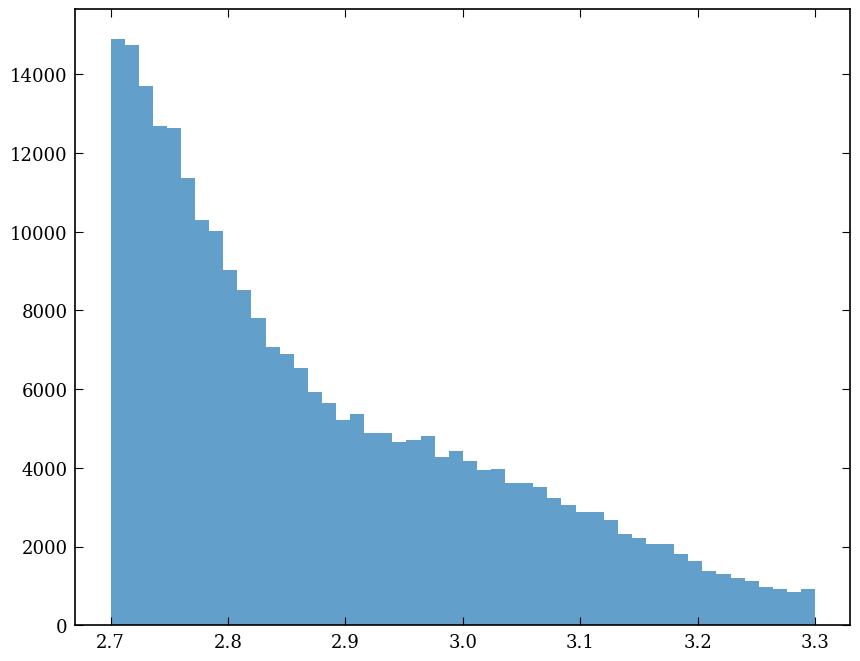

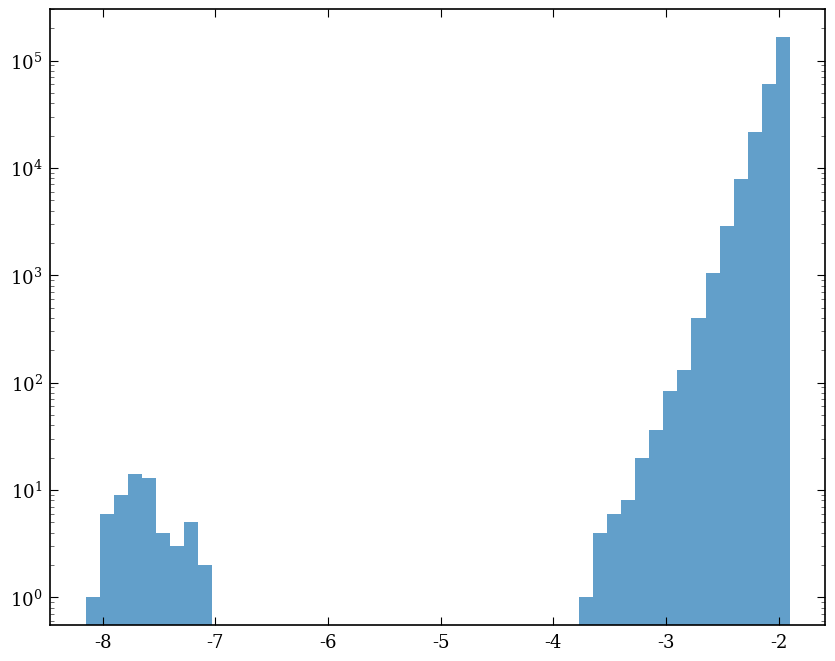

In [39]:
import matplotlib.pyplot as plt

plt.hist(exp_muon_Rue_df_large['recE'], bins=50, alpha=0.7, label='Experimental')
plt.show()
plt.hist(exp_muon_Rue_df_large['R_ue'], bins=50, alpha=0.7, label='Experimental')
plt.yscale('log')
plt.show()

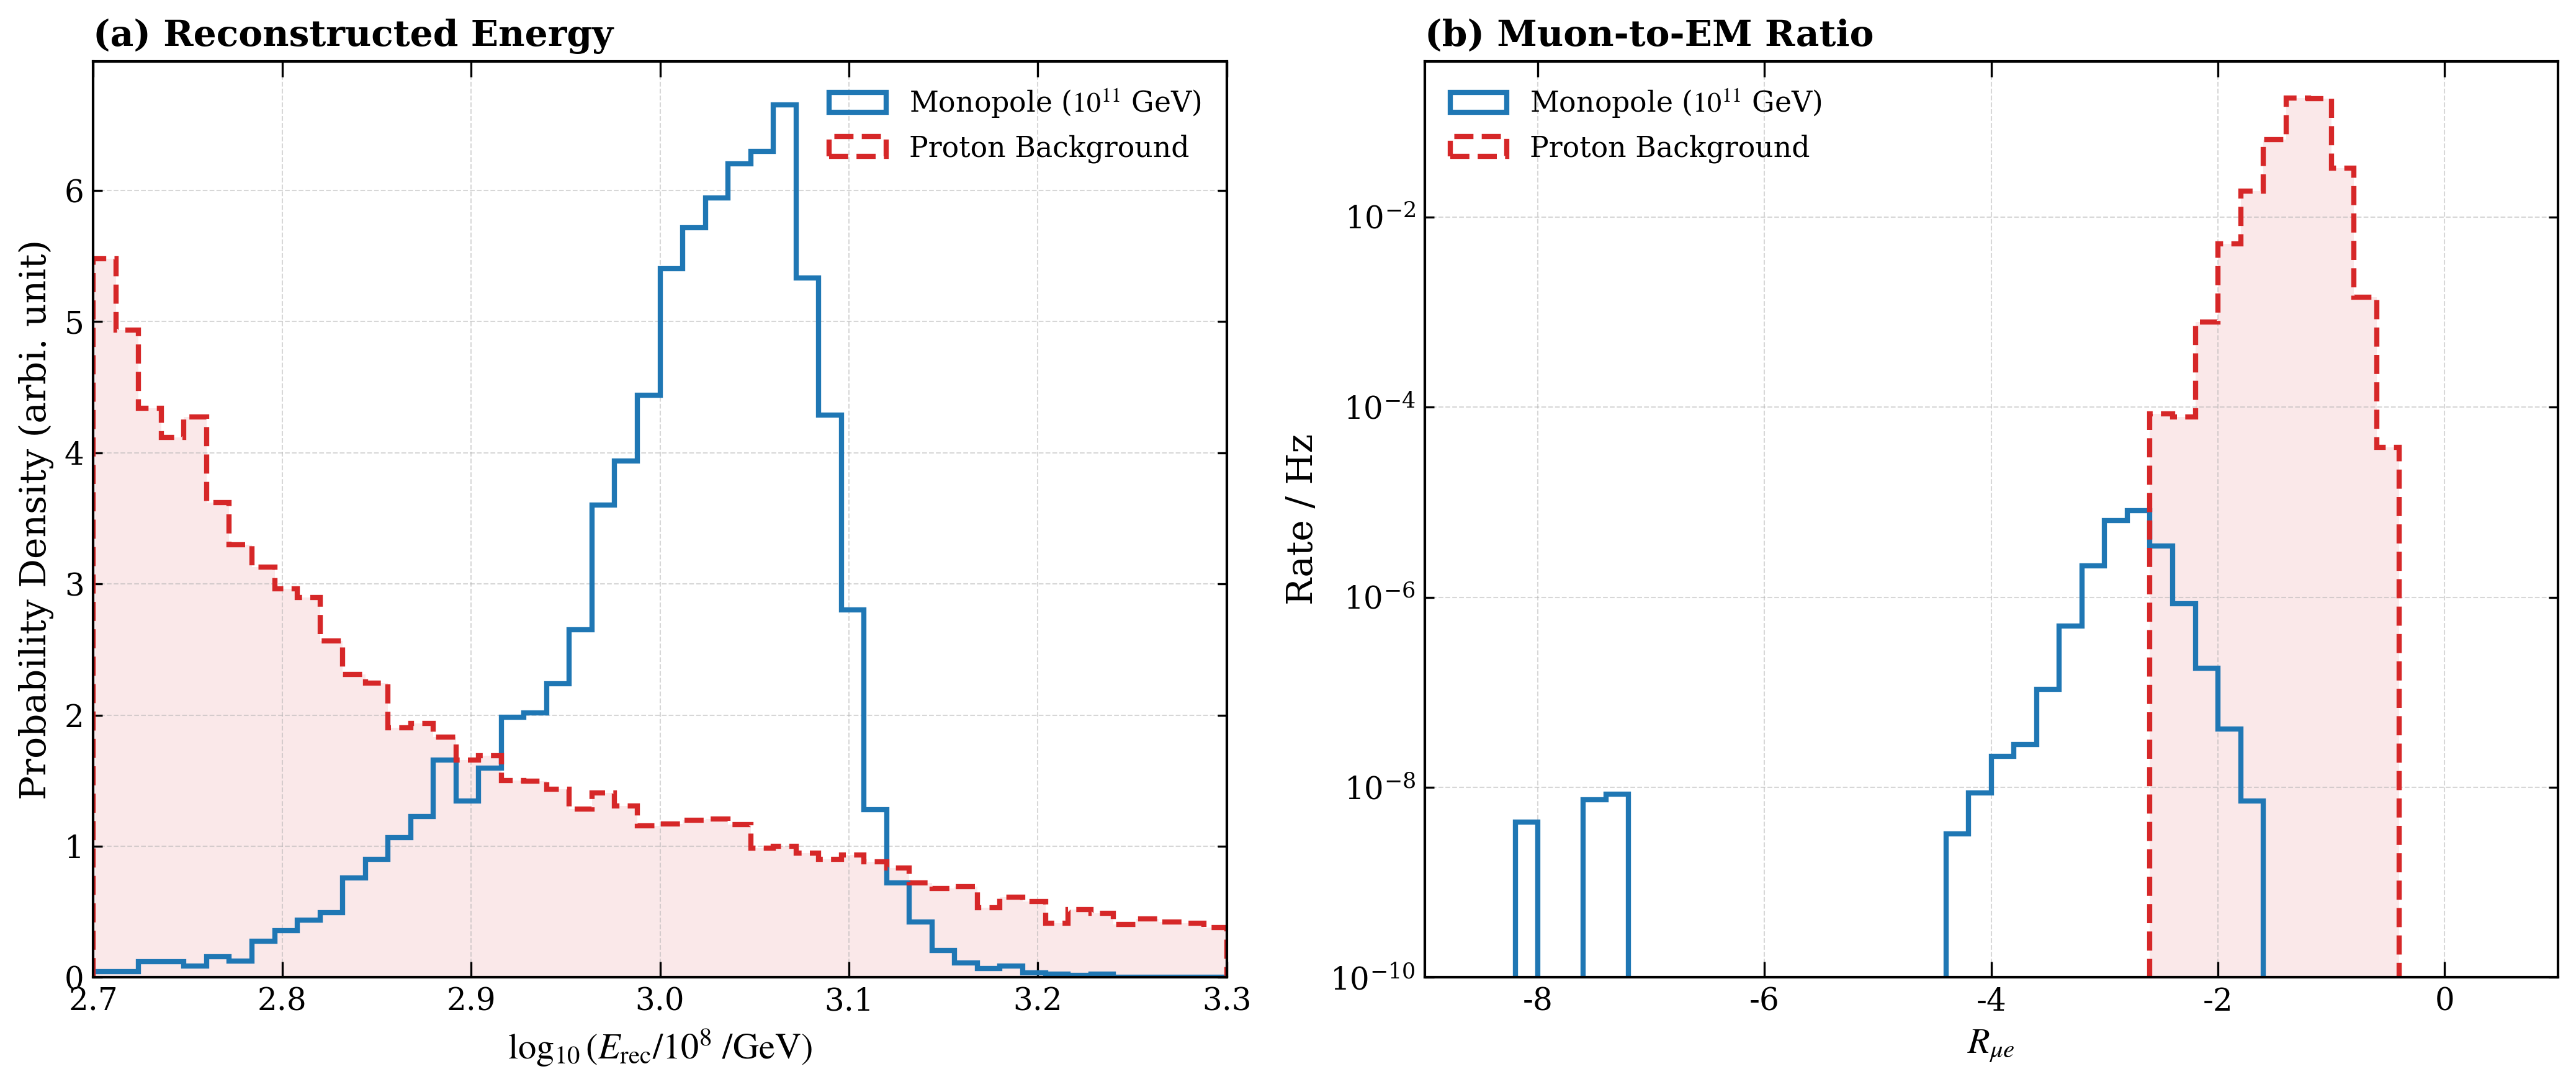

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_formal_recE_Rue(df_list: dict, bins=60, figsize=(14, 6)):
    """
    专门绘制 recE 和 R_ue 的正式对比图，支持权重。
    包含数据类型强制转换和鲁棒的字体设置。
    """
    # 1. 设置学术风格 (兼容 Linux 环境)
    # 如果找不到 Times New Roman，Matplotlib 会回退到 DejaVu Serif，这同样是符合学术标准的衬线体
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Liberation Serif", "serif"],
        "mathtext.fontset": "stix",
        "font.size": 12,
        "axes.unicode_minus": False,
        "axes.linewidth": 1.0,
        "xtick.major.size": 6,
        "xtick.minor.size": 3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True
    })

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, dpi=300)
    
    # 定义配色方案
    colors = ['#1f77b4', '#d62728', 'black', '#2ca02c'] 
    linestyles = ['-', '--', '-.', ':']

    # --- 绘图核心函数 ---
    def plot_variable(ax, param_name, x_range, log_y=False, x_label="", y_label=""):
        for idx, (label, df) in enumerate(df_list.items()):
            # 检查列是否存在
            if param_name not in df.columns:
                print(f"Warning: '{param_name}' not found in dataset '{label}'")
                continue
                
            # --- [修复核心] 强制转换为数值类型 ---
            # errors='coerce' 会将无法转换的字符串变成 NaN，避免 TypeError
            data_series = pd.to_numeric(df[param_name], errors='coerce')
            data = data_series.values
            
            # --- 权重处理 ---
            if 'gaisser_weight' in df.columns:
                w_series = pd.to_numeric(df['gaisser_weight'], errors='coerce')
                weights = w_series.values
            elif 'weight' in df.columns:
                w_series = pd.to_numeric(df['weight'], errors='coerce')
                weights = w_series.values
            else:
                weights = np.ones_like(data)

            # --- 数据清洗 (去 NaN) ---
            # 现在的 data 和 weights 都是 float 类型，np.isnan 可以正常工作了
            mask = ~np.isnan(data) & ~np.isnan(weights)
            
            # 额外过滤：只保留在 x_range 范围内的数据（可选，但推荐，防止极值破坏密度计算）
            if x_range:
                mask &= (data >= x_range[0]) & (data <= x_range[1])

            clean_data = data[mask]
            clean_weights = weights[mask]

            # 防止空数据报错
            if len(clean_data) == 0:
                print(f"Warning: No valid data for '{label}' in range {x_range}")
                continue

            # 计算加权直方图
            if param_name == "recE":
                counts, bin_edges = np.histogram(
                    clean_data, bins=bins, range=x_range, weights=clean_weights, density=True
                )
            elif param_name == "R_ue":
                counts, bin_edges = np.histogram(
                    clean_data, bins=bins, range=x_range, weights=clean_weights,
                )
            
            # 构造阶梯图数据
            bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
            
            c = colors[idx % len(colors)]
            ls = linestyles[idx % len(linestyles)]
            
            # 绘制 Step 线
            ax.hist(bin_centers, bins=bin_edges, weights=counts, histtype='step',
                    label=label, color=c, linewidth=2, linestyle=ls)
            
            # 填充效果
            if 'exp' in label.lower() or 'background' in label.lower():
                 ax.hist(bin_centers, bins=bin_edges, weights=counts, histtype='stepfilled',
                    color=c, alpha=0.1)

        # 轴修饰
        ax.set_xlabel(x_label, fontsize=14)
        ax.set_ylabel(y_label, fontsize=14)
        
        if x_range:
            ax.set_xlim(x_range)
        
        if log_y:
            ax.set_yscale('log')
            ax.set_ylim(bottom=1e-10) 
            
        ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.5)
        ax.legend(frameon=False, fontsize=11, loc='best')

    # --- 2. 绘制 recE (重建能量) ---
    plot_variable(
        ax1, 
        param_name="recE", 
        x_range=(2.7, 3.3), 
        log_y=False, 
        x_label=r"$\log_{10}(E_{\mathrm{rec}}{/10^{8}} ~/ \mathrm{GeV})$",
        y_label="Probability Density (arbi. unit)"
    )
    ax1.set_title("(a) Reconstructed Energy", loc='left', fontweight='bold', fontsize=14)

    # --- 3. 绘制 R_ue (μ/e 比率) ---
    plot_variable(
        ax2, 
        param_name="R_ue", 
        x_range=(-9, 1), 
        log_y=True, 
        x_label=r"$R_{\mu e}$",
        y_label="Rate / Hz"
    )
    ax2.set_title("(b) Muon-to-EM Ratio", loc='left', fontweight='bold', fontsize=14)

    plt.tight_layout()
    plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures/1e11_energy_rue_KeyParams_cut.pdf", bbox_inches='tight')
    plt.show()

# 这里的 df_list 需要你传入你的变量
# plot_formal_recE_Rue(df_list, bins=50)

# --- 使用示例 ---
# 假设你的 DataFrame 已经准备好
# exp_full_rue_df = pd.concat([exp_muon_Rue_df_large, exp_no_muon_cut_df[exp_no_muon_cut_df['R_ue'] > -1.9]], ignore_index=True)

df_list = {
    "Monopole ($10^{11}$ GeV)": mn_df_large,
    "Proton Background": pr_df_large,
    # "Experimental Data": exp_full_rue_df,
}

plot_formal_recE_Rue(df_list, bins=50)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.gridspec as gridspec

def plot_stability_with_ratio(df, sideband_thresholds=[-2.6, -2.65, -2.7, -2.75, -2.80], 
                              SR_limit=-2.85, reference_thresh=-2.7, BINS_PLOT=30):
    features = ['rec_theta', 'Eage', 'rho40', 'pincness', 'compactness','R_mean']
    
    # 创建画布
    fig = plt.figure(figsize=(20, 12))
    # 定义 2行 3列 的大网格
    outer_grid = gridspec.GridSpec(2, 3, fig, wspace=0.3, hspace=0.3)
    
    colors = sns.color_palette("tab10", len(sideband_thresholds))
    
    # 参考区间的 Mask (Nominal)
    ref_mask = (df['R_ue'] <= reference_thresh) & (df['R_ue'] > SR_limit)
    
    for i, col in enumerate(features):
        # 在每个大网格里切分出上下两个子图，高度比为 3:1
        inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_grid[i], 
                                                      height_ratios=[3, 1], hspace=0.05)
        
        ax_main = plt.Subplot(fig, inner_grid[0])
        ax_ratio = plt.Subplot(fig, inner_grid[1], sharex=ax_main)
        fig.add_subplot(ax_main)
        fig.add_subplot(ax_ratio)
        
        # --- 准备基准数据 (Reference) ---
        data_ref = df[ref_mask][col].dropna()
        # 统一使用 40 个 bin
        counts_ref, bin_edges = np.histogram(data_ref, bins=BINS_PLOT, density=True)
        # counts_ref, bin_edges = np.histogram(sig_df_recE[col].dropna(), bins=BINS_PLOT, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        # --- 循环绘制不同 Threshold ---
        for j, thresh in enumerate(sideband_thresholds):
            mask_sub = (df['R_ue'] <= thresh) & (df['R_ue'] > SR_limit)
            # print(f"Processing {col} with threshold {thresh}: {mask_sub.sum()} entries")
            data_sub = df[mask_sub][col].dropna()
            
            if len(data_sub) < 10: continue
            
            # 计算直方图
            counts_sub, _ = np.histogram(data_sub, bins=bin_edges, density=True)
            
            # 1. 上方主图: Density
            ax_main.step(bin_edges, np.append(counts_sub, counts_sub[-1]), where='post', 
                         color=colors[j], lw=1.5, label=f"{SR_limit} < R_ue < {thresh} (N={len(data_sub)})")
            
            # 2. 下方副图: Ratio
            # 处理除零
            ratio = np.divide(counts_sub, counts_ref, out=np.ones_like(counts_sub), where=counts_ref!=0)
            ax_ratio.step(bin_edges, np.append(ratio, ratio[-1]), where='post', color=colors[j], lw=1.5)
            
            # 统计误差带 (Poisson)
            rel_err = np.sqrt(1/len(data_sub) + 1/len(data_ref)) if (len(data_sub)>0 and len(data_ref)>0) else 0
            # ax_ratio.fill_between(bin_centers, ratio*(1-rel_err), ratio*(1+rel_err), color=colors[j], alpha=0.1)

        # ax_main.hist(data_SR[col].dropna(), bins=bin_edges, density=True, histtype='stepfilled',  lw=2, label=f"SR (R_ue ≤ {SR_limit})")
        # ax_main.hist(sig_df_recE[col].dropna(), bins=bin_edges, density=True, histtype='step', lw=2, label=f"Signal (R_ue ≤ {SR_limit})")
        # --- 图表装饰 ---
        # 主图
        # ax_main.set_title(f"Stability & Ratio: {col}", fontsize=14, fontweight='bold')
        ax_main.set_ylabel("Density")
        ax_main.legend(fontsize='x-small', loc='best', frameon=False)
        plt.setp(ax_main.get_xticklabels(), visible=False) # 隐藏主图 X 轴刻度
        
        # 副图
        ax_ratio.axhline(1.0, color='black', linestyle='--', alpha=0.5)
        ax_ratio.set_ylim(0., 2) # Ratio 范围设定
        ax_ratio.set_ylabel("Ratio / Ref", fontsize=10)
        ax_ratio.set_xlabel(col)
        ax_ratio.grid(True, which='both', linestyle=':', alpha=0.5)

    # 移除最后一个空白子图
    # fig.delaxes(fig.axes[-1])
    # fig.delaxes(fig.axes[-1]) 
    
    # plt.tight_layout()
    plt.show()

# 调用
SR_Emin = 2.85
SR_Emax = 3.1
SR_Ruelimit = -2.6
SR_Ruelimit_low = -4.5
BINS_PLOT = 30
sideband_thresholds = [-1.9, -2.1, -2.2, -2.3, -2.4, ]
reference_thresh = -2.2
exp_muon_Rue_df_large_recE = exp_muon_Rue_df_large[(exp_muon_Rue_df_large['recE'] > SR_Emin) & (exp_muon_Rue_df_large['recE'] < SR_Emax)]
sig_df_recE = mn_df_large[(mn_df_large['recE'] > SR_Emin) & (mn_df_large['recE'] < SR_Emax) & (mn_df_large['R_ue'] <= SR_Ruelimit)]

data_SR = exp_muon_Rue_df_large_recE[exp_muon_Rue_df_large_recE['R_ue'] <= SR_Ruelimit]
plot_stability_with_ratio(exp_muon_Rue_df_large_recE, SR_limit=SR_Ruelimit, sideband_thresholds=sideband_thresholds, reference_thresh=reference_thresh, BINS_PLOT=BINS_PLOT)


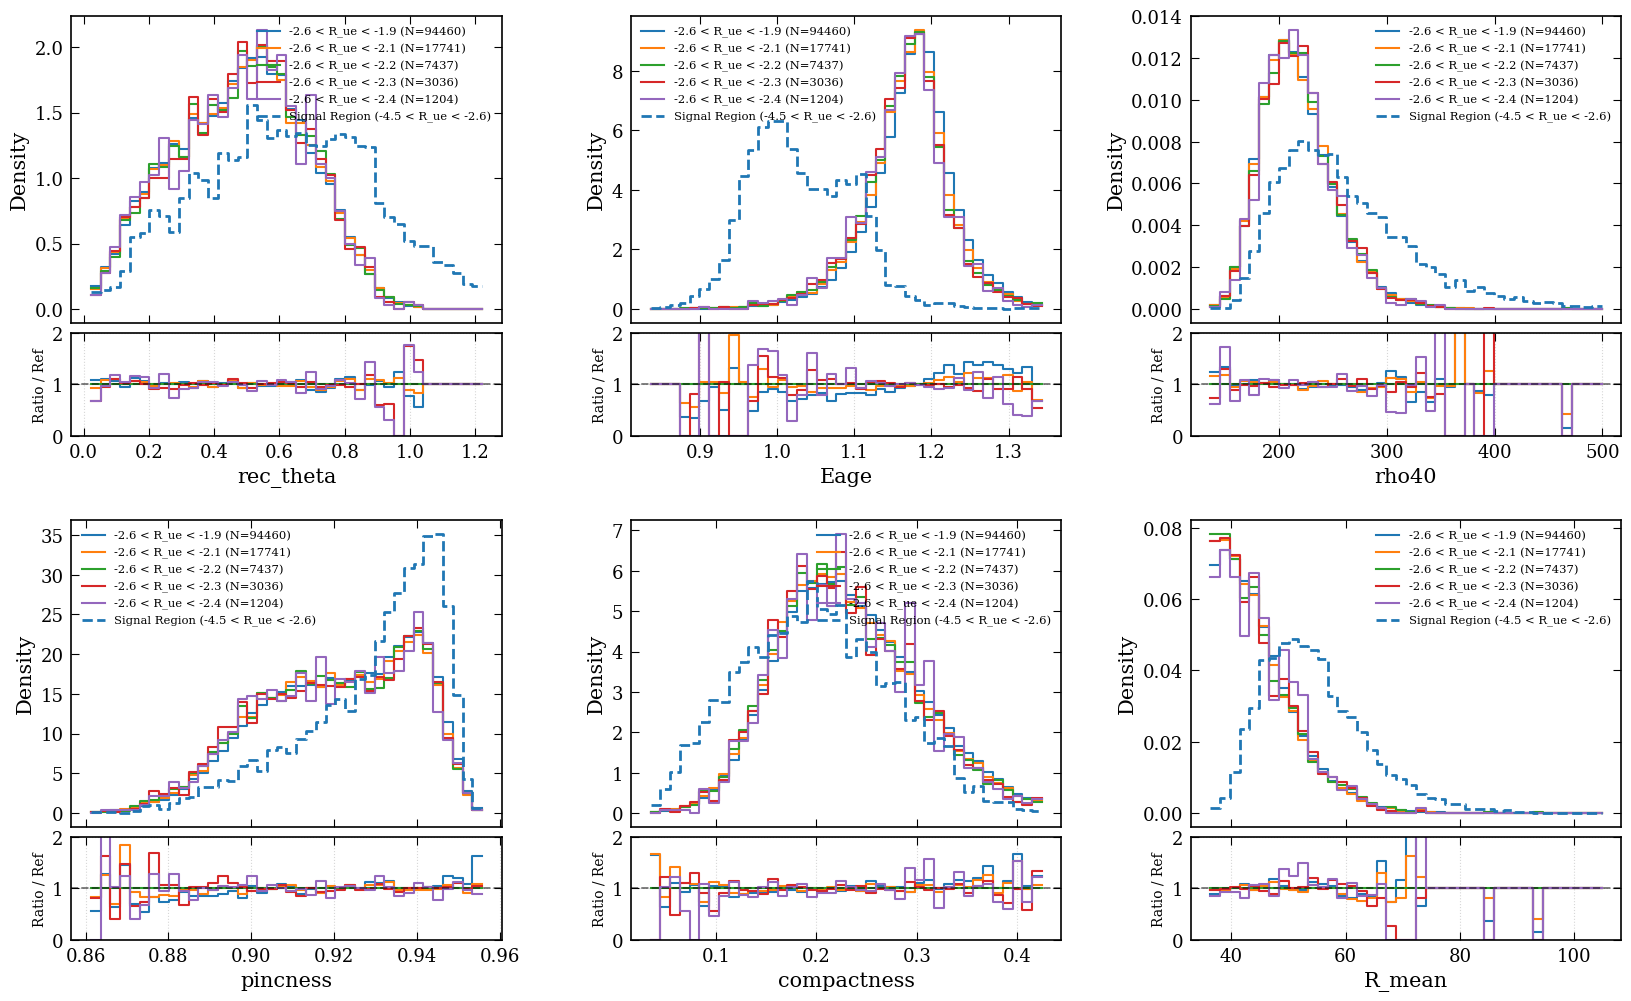

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.gridspec as gridspec

def plot_stability_with_ratio(df, sideband_thresholds=[-1.9, -2.1, -2.2, -2.3, -2.4, ], 
                              SR_limit=-2.2, reference_thresh=-2.2):
    features = ['rec_theta', 'Eage', 'rho40', 'pincness', 'compactness','R_mean']
    
    # 创建画布
    fig = plt.figure(figsize=(20, 12))
    # 定义 2行 3列 的大网格
    outer_grid = gridspec.GridSpec(2, 3, fig, wspace=0.3, hspace=0.2)
    
    colors = sns.color_palette("tab10", len(sideband_thresholds))
    
    # 参考区间的 Mask (Nominal)
    ref_mask = (df['R_ue'] <= reference_thresh) & (df['R_ue'] > SR_limit)
    
    for i, col in enumerate(features):
        # 在每个大网格里切分出上下两个子图，高度比为 3:1
        inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_grid[i], 
                                                      height_ratios=[3, 1], hspace=0.05)
        
        ax_main = plt.Subplot(fig, inner_grid[0])
        ax_ratio = plt.Subplot(fig, inner_grid[1], sharex=ax_main)
        fig.add_subplot(ax_main)
        fig.add_subplot(ax_ratio)
        
        # --- 准备基准数据 (Reference) ---
        data_ref = df[ref_mask][col].dropna()
        # 统一使用 40 个 bin
        counts_sig, bin_edges = np.histogram(sig_SR_df[col].dropna(), bins=40, density=True, weights=sig_SR_df['weight'].dropna())
        
        counts_ref, _ = np.histogram(data_ref, bins=bin_edges, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        # --- 循环绘制不同 Threshold ---
        for j, thresh in enumerate(sideband_thresholds):
            mask_sub = (df['R_ue'] <= thresh) & (df['R_ue'] > SR_limit)
            data_sub = df[mask_sub][col].dropna()
            
            if len(data_sub) < 10: continue
            
            # 计算直方图
            counts_sub, _ = np.histogram(data_sub, bins=bin_edges, density=True)
            
            # 1. 上方主图: Density
            ax_main.step(bin_edges, np.append(counts_sub, counts_sub[-1]), where='post', 
                         color=colors[j], lw=1.5, label=f"{SR_limit} < R_ue < {thresh} (N={len(data_sub)})")
            
            # 2. 下方副图: Ratio
            # 处理除零
            ratio = np.divide(counts_sub, counts_ref, out=np.ones_like(counts_sub), where=counts_ref!=0)
            ax_ratio.step(bin_edges, np.append(ratio, ratio[-1]), where='post', color=colors[j], lw=1.5)
            
            # # 统计误差带 (Poisson)
            # rel_err = np.sqrt(1/len(data_sub) + 1/len(data_ref)) if (len(data_sub)>0 and len(data_ref)>0) else 0
            # ax_ratio.fill_between(bin_centers, ratio*(1-rel_err), ratio*(1+rel_err), color=colors[j], alpha=0.1)

        # --- 图表装饰 ---
        # 主图
        # ax_main.set_title(f"Stability & Ratio: {col}", fontsize=14, fontweight='bold')
        ax_main.step(bin_edges, np.append(counts_sig, counts_sig[-1]), where='post', lw=2, label=f"Signal Region ({SR_Ruelimit_low} < R_ue < {SR_Ruelimit})", linestyle='--')
        ax_main.set_ylabel("Density")
        ax_main.legend(fontsize='x-small', loc='best', frameon=False)
        plt.setp(ax_main.get_xticklabels(), visible=False) # 隐藏主图 X 轴刻度
        
        # 副图
        ax_ratio.axhline(1.0, color='black', linestyle='--', alpha=0.5)
        ax_ratio.set_ylim(0., 2) # Ratio 范围设定
        ax_ratio.set_ylabel("Ratio / Ref", fontsize=10)
        ax_ratio.set_xlabel(col)
        ax_ratio.grid(True, which='both', linestyle=':', alpha=0.5)

    # 移除最后一个空白子图
    # fig.delaxes(fig.axes[-1])
    # fig.delaxes(fig.axes[-1]) 
    
    # plt.tight_layout()
    plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures/1e11_Rue_cut_stability.pdf", dpi=300)
    plt.show()

# 调用
SR_Emin = 2.85
SR_Emax = 3.1
SR_Ruelimit = -2.6
SR_Ruelimit_low = -4.5
sideband_thresholds = [-1.9, -2.1, -2.2, -2.3, -2.4, ]
reference_thresh = -2.2
sig_SR_df = mn_df_large[(mn_df_large['R_ue']<SR_Ruelimit) & (mn_df_large['R_ue'] > SR_Ruelimit_low) & (mn_df_large['recE']>SR_Emin) & (mn_df_large['recE']<SR_Emax)]
exp_muon_Rue_df_large_recE = exp_muon_Rue_df_large[(exp_muon_Rue_df_large['recE'] > SR_Emin) & (exp_muon_Rue_df_large['recE'] < SR_Emax) & (exp_muon_Rue_df_large['R_ue'] > SR_Ruelimit_low)]
plot_stability_with_ratio(exp_muon_Rue_df_large_recE, SR_limit=SR_Ruelimit)


[  32.   36.   47.   47.   56.   68.   71.   93.   91.  133.  127.  144.
  168.  225.  216.  280.  327.  350.  429.  527.  617.  712.  752.  912.
 1083.]


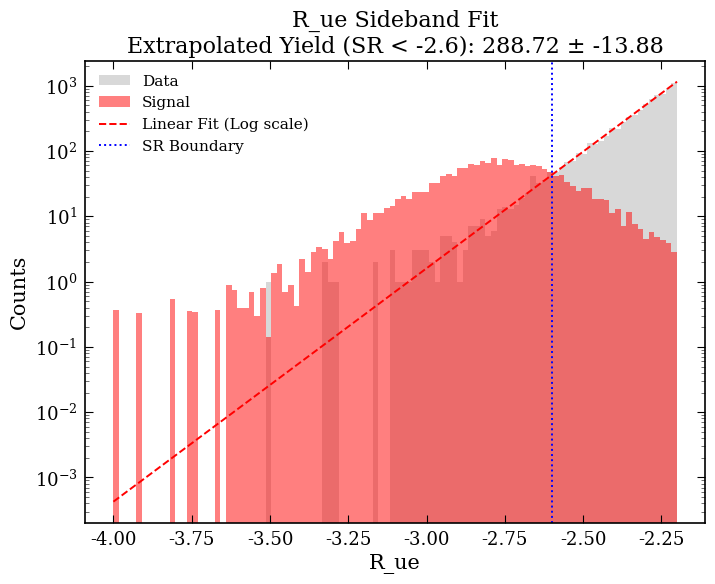

Extrapolated Yield: 296.23 ± 14.49 (stat) ± 5.82 (syst)
Actual yield in lowE CR: 136.00
[ 11.  13.  25.  21.  23.  38.  38.  47.  46.  65.  64.  71.  79. 117.
 114. 150. 161. 176. 219. 251. 319. 356. 397. 448. 571.]
Validation region gap: 0.92%


In [45]:
import seaborn as sns
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.gridspec as gridspec
def sideband_extrapolation(df, sr_threshold=-2.85, fit_range=(-2.8, -2.3), bins=50, plot=True):
    # 1. Prepare Histogram Data
    # df = df[df['R_ue'] > sr_threshold]  # Focus on sideband region
    # df = df[df['R_ue'] < fit_range[1]]  # Ensure we have data in the fit range
    counts, bin_edges = np.histogram(df['R_ue'], bins=bins, range=(-4, fit_range[1]), weights=df['weight'])
    counts = counts.astype(float)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = np.diff(bin_edges)[0]
    # Filter for fit range (sideband)
    fit_mask = (bin_centers >= fit_range[0]) & (bin_centers <= fit_range[1]) & (counts > 0)
    x_fit = bin_centers[fit_mask]
    print(counts[fit_mask])
    y_fit = np.log10(counts[fit_mask] / bin_width)
    y_err = 1 / (np.sqrt(counts[fit_mask]) * np.log(10)) # Log error propagation
    
    # 2. Linear Fit: log10(y) = a*x + b
    def linear_func(x, a, b):
        return a * x + b
    
    popt, pcov = curve_fit(linear_func, x_fit, y_fit, sigma=y_err, absolute_sigma=True)
    a, b = popt
    perr = np.sqrt(np.diag(pcov))
    
    # 3. Extrapolation & Integration
    # The yield Y = 10^(ax+b). Integral from -inf to sr_threshold:
    # Integral = [ 10^(ax+b) / (a * ln(10)) ]
    def get_yield(cutoff, a_val, b_val):
        return (10**(a_val * cutoff + b_val)) / (a_val * np.log(10))
    
    extrapolated_yield = get_yield(sr_threshold, a, b) - get_yield(-4, *popt)
    
    # 4. Uncertainty (Simplified via Jacobian or Delta Method)
    # For speed, we estimate by varying parameters within 1-sigma
    yield_up = get_yield(sr_threshold, a + perr[0], b + perr[1])
    yield_down = get_yield(sr_threshold, a - perr[0], b - perr[1])
    uncertainty = (yield_up - yield_down) / 2
    if plot:
        # 5. Plotting
        plt.figure(figsize=(8, 6))
        plt.hist(df['R_ue'], bins=bins, range=(-4, fit_range[1]), weights=df['weight'],label='Data', color='gray', alpha=0.3)
        plt.hist(sig_df_recE_new['R_ue'], bins=bins, range=(-4, fit_range[1]), weights=sig_df_recE_new['weight']*365*86400*3, label='Signal', color='red', alpha=0.5)
        x_plot = np.linspace(-4, fit_range[1], 100)
        plt.plot(x_plot, 10**linear_func(x_plot, *popt) * bin_width, 'r--', label='Linear Fit (Log scale)')
        plt.axvline(sr_threshold, color='blue', linestyle=':', label='SR Boundary')
        
        plt.yscale('log')
        plt.title(f"R_ue Sideband Fit\nExtrapolated Yield (SR < {sr_threshold}): {extrapolated_yield:.2f} ± {uncertainty:.2f}")
        plt.xlabel("R_ue")
        plt.ylabel("Counts")
        plt.legend()
        plt.show()
    
    return extrapolated_yield, uncertainty


def sideband_extrapolation_refined(df, sr_threshold=-2.85, fit_range=(-2.8, -2.3), bins=100):
    # --- A. 数据准备 ---
    counts, bin_edges = np.histogram(df['R_ue'], bins=bins, range=(-4, df['R_ue'].max()), weights=df['weight'])
    counts = counts.astype(float)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]
    
    fit_mask = (bin_centers >= fit_range[0]) & (bin_centers <= fit_range[1]) & (counts > 0)
    x_fit, y_fit = bin_centers[fit_mask], np.log10(counts[fit_mask] / bin_width)
    y_err = 1 / (np.sqrt(counts[fit_mask]) * np.log(10)) 

    # --- B. 统计误差：从协方差矩阵采样 ---
    def linear_func(x, a, b): return a * x + b
    popt, pcov = curve_fit(linear_func, x_fit, y_fit, sigma=y_err, absolute_sigma=True)
    
    # 使用 2000 次采样传播统计误差
    samples = np.random.multivariate_normal(popt, pcov, 2000)
    def calc_y(cutoff, a_v, b_v): return (10**(a_v * cutoff + b_v)) / (a_v * np.log(10))
    
    stats_yields = [calc_y(sr_threshold, s[0], s[1]) for s in samples]
    central_yield = calc_y(sr_threshold, *popt) - calc_y(-4, *popt)  # 减去 -4 到 -inf 的贡献
    stat_err = np.std(stats_yields)

    # --- C. 系统误差：拟合量程变化 (Fit Range Variation) ---
    # 改变拟合边界看 Yield 漂移（例如左右移动 0.1）
    size_x =len(x_fit)
    percent_shift = 0.1
    size_shift = int(size_x * percent_shift)
    yield_var1 = calc_y(sr_threshold, *curve_fit(linear_func, x_fit[:-size_shift], y_fit[:-size_shift], sigma=y_err[:-size_shift])[0])
    yield_var2 = calc_y(sr_threshold, *curve_fit(linear_func, x_fit[size_shift:], y_fit[size_shift:], sigma=y_err[size_shift:])[0])
    syst_err_range = np.abs(yield_var1 - yield_var2) / 2.0
    
    return central_yield, stat_err, syst_err_range


# Run extrapolation
exp_temp_df_CRrecE = exp_muon_Rue_df_large[(exp_muon_Rue_df_large['recE'] > SR_Emin) & (exp_muon_Rue_df_large['recE'] < SR_Emax)]
sig_df_recE_new = mn_df_large[(mn_df_large['recE'] > SR_Emin) & (mn_df_large['recE'] < SR_Emax)]
fit_range = (SR_Ruelimit - 0.05, -2.2)
bins_linearfit=100
yield_sr, err_sr = sideband_extrapolation(exp_temp_df_CRrecE,sr_threshold=SR_Ruelimit, bins=bins_linearfit, fit_range=fit_range, plot=True)
linear_yield = yield_sr
# 调用
linear_y, linear_stat, linear_syst = sideband_extrapolation_refined(exp_temp_df_CRrecE, sr_threshold=SR_Ruelimit, bins=bins_linearfit, fit_range=fit_range)
print(f"Extrapolated Yield: {linear_y:.2f} ± {linear_stat:.2f} (stat) ± {linear_syst:.2f} (syst)")

# validation recE 1.9-1.95
exp_temp_df = exp_muon_Rue_df_large
exp_temp_df_CRrecE_lowE = exp_temp_df[(exp_temp_df['recE'] > SR_Emax-0.15) & (exp_temp_df['recE'] < SR_Emax)]
actual_yield_lowE = exp_temp_df_CRrecE_lowE[(exp_temp_df_CRrecE_lowE['R_ue'] < SR_Ruelimit)&(exp_temp_df_CRrecE_lowE['R_ue'] > -5)]['weight'].sum()
print(f"Actual yield in lowE CR: {actual_yield_lowE:.2f}")
yield_sr_lowE, err_sr_lowE = sideband_extrapolation(exp_temp_df_CRrecE_lowE, sr_threshold=SR_Ruelimit, fit_range=fit_range, bins=bins_linearfit, plot=False)
validation_region_gap = np.abs(yield_sr_lowE - actual_yield_lowE)/yield_sr_lowE
print(f"Validation region gap: {validation_region_gap:.2%}")


In [46]:
sig_check = sig_df_recE_new[(sig_df_recE_new['R_ue'] > SR_Ruelimit)]['weight'].sum() * 365*86400*3
print(f"Signal yield in CR: {sig_check:.2f}")
sig_check_SR = sig_df_recE_new[(sig_df_recE_new['R_ue'] < SR_Ruelimit)]['weight'].sum() * 365*86400*3
print(f"Signal yield in SR: {sig_check_SR:.2f}")
CR_bkg_check = exp_temp_df_CRrecE[(exp_temp_df_CRrecE['R_ue'] > SR_Ruelimit)]['weight'].sum()
print(f"CR background yield in SR: {CR_bkg_check:.2f}")
ratio_check = CR_bkg_check/sig_check if sig_check > 0 else float('inf')
print(f"CR/Sig ratio in SR: {1/ratio_check:.4f}")

Signal yield in CR: 390.44
Signal yield in SR: 1486.27
CR background yield in SR: 94460.00
CR/Sig ratio in SR: 0.0041


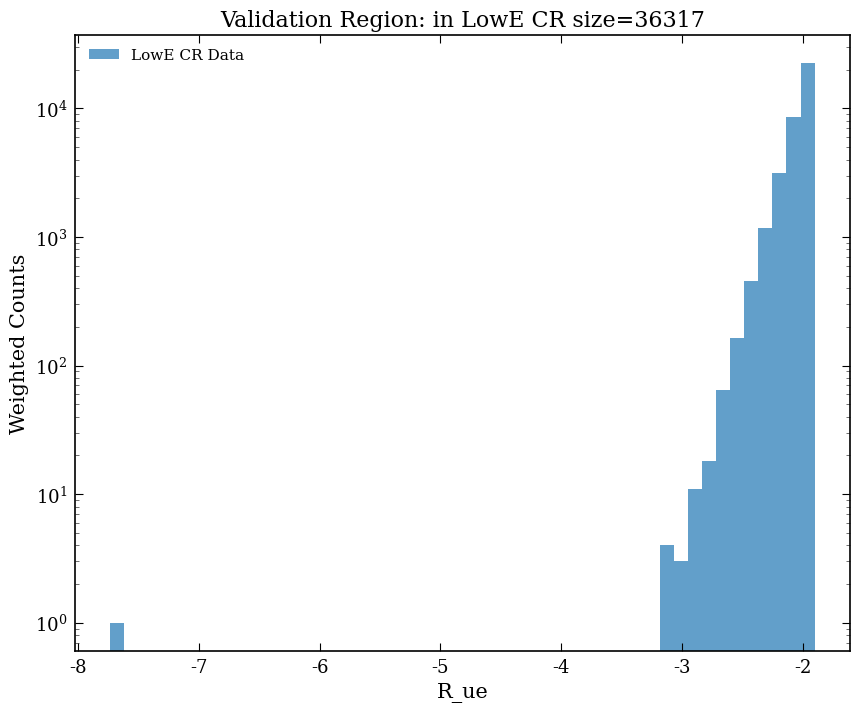

In [103]:
plt.hist(exp_temp_df_CRrecE_lowE['R_ue'], bins=50, weights=exp_temp_df_CRrecE_lowE['weight'], alpha=0.7, label='LowE CR Data')
plt.xlabel("R_ue")
plt.ylabel("Weighted Counts")
plt.title(f"Validation Region: in LowE CR size={len(exp_temp_df_CRrecE_lowE)}")
plt.legend()
plt.yscale('log')
plt.show()

when use R_ue > -1.90 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 0.00 ± 0.00
when use R_ue > -1.94 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 0.50 ± 0.06
when use R_ue > -1.99 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 0.92 ± 0.09
when use R_ue > -2.03 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 1.48 ± 0.13
when use R_ue > -2.08 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 2.03 ± 0.16


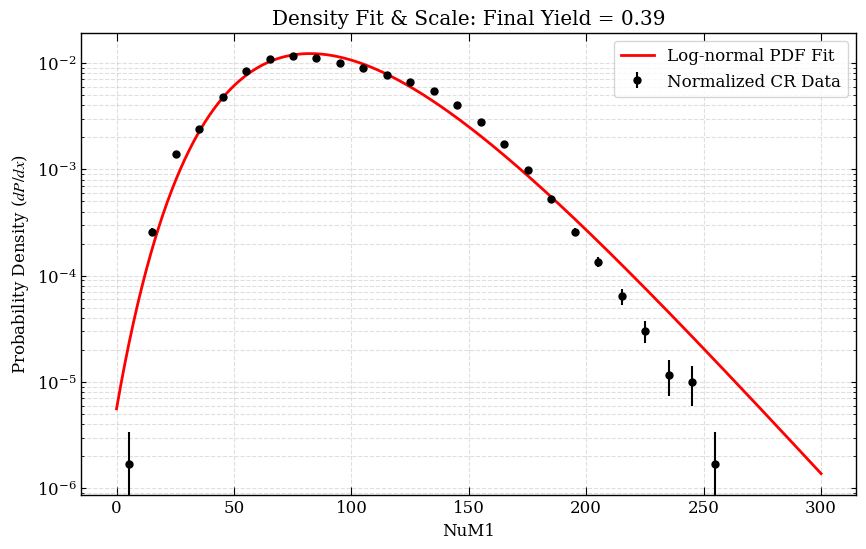

when use R_ue > -2.12 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 0.39 ± 0.03
when use R_ue > -2.17 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 0.59 ± 0.04
when use R_ue > -2.21 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 0.59 ± 0.05
when use R_ue > -2.26 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 0.79 ± 0.06
when use R_ue > -2.30 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 1.43 ± 0.09
when use R_ue > -2.35 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 2.00 ± 0.12
when use R_ue > -2.39 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 2.67 ± 0.16
when use R_ue > -2.44 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 3.24 ± 0.18
when use R_ue > -2.48 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 3.94 ± 0.21
when use R_ue > -2.53 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 4.18 ± 0.22
when use R_ue > -2.57 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 4.84 ± 0.25
when use R_ue > -2.62 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 5.28 ± 0.26
when use R_ue > -2.66 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 5.63 ± 0.28
when use R_ue > -2.71 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 6.12 ± 0.30
when use R_ue > -2.75 data, 通过 CR 拟合外推得到的 NuM1=0

/data/home/zzh/miniconda3/envs/root_env/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


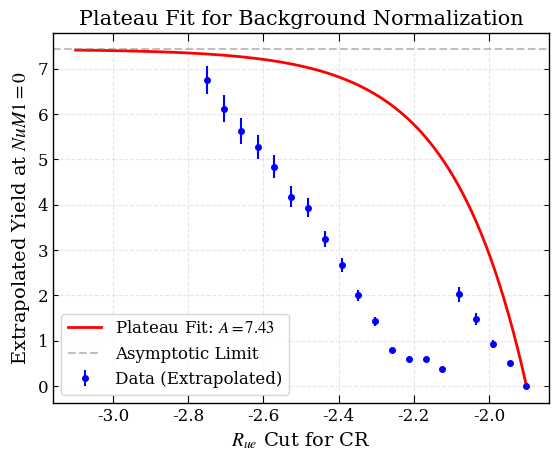

Zero-Muon 组件: 7.43 ± 40.02 (Stat) ± 0.66 (Syst)


In [67]:

from scipy.stats import moyal
from scipy.optimize import curve_fit
from scipy.stats import lognorm
import scipy.integrate as integrate


def extrapolate_zero_muon_yield(df, sr_threshold=-2.85, fit_range=(0.2, 300),integral_range=(0,1), bins=30, plot=False):
    # 1. 划定 Control Region (CR) 并计算总权重
    cr_mask = (df['R_ue'] > sr_threshold) & (df['NuM1'] >= fit_range[0]) & (df['NuM1'] <= fit_range[1])
    df_cr = df[cr_mask]
    total_weight = df_cr['weight'].sum() # 关键：用于最后的 scale
    
    if total_weight == 0:
        return 0.0, 0.0

    # 2. 提取归一化密度直方图 (density=True)
    # 此时 counts 代表的是 dP/dx，即单位 x 的概率
    counts, bin_edges = np.histogram(df_cr['NuM1'], bins=bins, range=fit_range, 
                                     weights=df_cr['weight'], density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]
    
    # 计算密度的误差 (Propagation of errors for normalized density)
    # Error(Density) = sqrt(sum(w^2)) / (Total_Weight * bin_width)
    counts_sq, _ = np.histogram(df_cr['NuM1'], bins=bins, range=fit_range, weights=df_cr['weight']**2)
    counts_sq = counts_sq.astype(float)
    y_err = np.sqrt(counts_sq) / (total_weight * bin_width)
    
    valid_mask = (counts > 0)
    x_fit = bin_centers[valid_mask]
    y_fit = counts[valid_mask]
    y_err = y_err[valid_mask]

    # 3. 定义拟合函数 (作为 PDF 的幅值修正)
    def lognorm_pdf(x, amplitude, s, loc, scale):
        return amplitude * lognorm.pdf(x, s=s, loc=loc, scale=scale)

    # 初始猜测：因为是 density=True，amplitude 应该在 1 附近
    peak_idx = np.argmax(y_fit)
    p0 = [1.0, 0.7, 0, x_fit[peak_idx]]
    
    # 4. 执行曲线拟合
    try:
        popt, pcov = curve_fit(lognorm_pdf, x_fit, y_fit, p0=p0, sigma=y_err, 
                               absolute_sigma=True, maxfev=20000)
    except RuntimeError:
        print("Fit failed.")
        return 0.0, 0.0
    
    # 5. 积分计算概率 P(0 < NuM1 < 0.2)
    prob_extrap, _ = integrate.quad(lognorm_pdf, integral_range[0], integral_range[1], args=tuple(popt))
    
    # 6. 最终结果：概率 * 总权重
    yield_extrap = prob_extrap * total_weight
    
    # 7. 误差传播 (蒙特卡洛采样)
    samples = np.random.multivariate_normal(popt, pcov, 1000)
    integrals = []
    for samp in samples:
        try:
            if samp[1] <= 0 or samp[3] <= 0: continue 
            val, _ = integrate.quad(lognorm_pdf, integral_range[0], integral_range[1], args=tuple(samp))
            integrals.append(val * total_weight)
        except:
            continue
    yield_extrap_err = np.std(integrals) if len(integrals) > 0 else 0.0

    if plot:
        plt.figure(figsize=(10, 6))
        # 此时 y 轴是 Density (Probability per unit x)
        plt.errorbar(x_fit, y_fit, yerr=y_err, fmt='ko', label='Normalized CR Data', markersize=5)
        
        x_plot = np.linspace(0, fit_range[1], 1000)
        y_plot = lognorm_pdf(x_plot, *popt)
        plt.plot(x_plot, y_plot, 'r-', linewidth=2, label=f'Log-normal PDF Fit')
        
        plt.yscale('log')
        plt.title(f"Density Fit & Scale: Final Yield = {yield_extrap:.2f}")
        plt.xlabel("NuM1")
        plt.ylabel("Probability Density ($dP/dx$)")
        plt.legend()
        plt.grid(True, which="both", ls="--", alpha=0.4)
        plt.show()

    return yield_extrap, yield_extrap_err
extrap_yield_list = []
extrap_err_list = []
Rue_cut_values = np.linspace(-1.9, SR_Ruelimit, 20)  # 从 -2.6 到 -2.85，25 个点
for i, Rue_cut in enumerate(Rue_cut_values):
    plot=False
    if i == 0 or i==5:
        plot = True
    else:        plot = False
    extrap_yield, extrap_err = extrapolate_zero_muon_yield(exp_temp_df_CRrecE, sr_threshold=Rue_cut, plot=plot)
    extrap_yield_list.append(extrap_yield)
    extrap_err_list.append(extrap_err)
    print(f"when use R_ue > {Rue_cut:.2f} data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: {extrap_yield:.2f} ± {extrap_err:.2f}")
    
# plt.errorbar(Rue_cut_values, extrap_yield_list, yerr=extrap_err_list, fmt='o-', color='blue')
# plt.xlabel("R_ue Cut for CR")
# plt.ylabel("Extrapolated Yield at NuM1=0")
# plt.title("Extrapolated Zero-Muon Yield vs R_ue Cut")
# plt.grid(True, ls="--", alpha=0.5)
# plt.show()

from scipy.optimize import curve_fit

# 1. 定义函数：A 是我们要找的极限（平台），B*exp(Cx) 是偏离项
def plateau_func(x, A, B, C):
    return A - B * np.exp(C * x)

# 2. 更加物理的初始值猜测 (Initial Guess)
# A 应该比现在的最大值（约640）稍大一点
y_max = np.max(extrap_yield_list)
y_min = np.min(extrap_yield_list)
p0_A = y_max * 1.1 

# 粗略估算 C。假设 y1 = A - B*exp(Cx1), y2 = A - B*exp(Cx2)
# 取首尾两点通过变化率估算 C 约为 5~10 左右
p0_C = 5.0 

# 推导 B：B = (A - y_min) / exp(C * x_min)
p0_B = (p0_A - y_min) / np.exp(p0_C * Rue_cut_values[0])

# 3. 执行带边界的拟合
# Bounds: A > y_max, B > 0, C > 0
try:
    popt, pcov = curve_fit(
        plateau_func, 
        Rue_cut_values, 
        extrap_yield_list, 
        p0=[p0_A, p0_B, p0_C],
        sigma=extrap_err_list,        # 加入权重
        absolute_sigma=True,
        bounds=([y_max, 0, 0], [y_max*5, np.inf, 20]), # 设定合理边界
        maxfev=100000
    )
    print(f"Fitted parameters: A={popt[0]:.2f}, B={popt[1]:.2f}, C={popt[2]:.2f}")
    print(f"covariance matrix:\n{pcov}")
    perr = np.sqrt(np.diag(pcov))
    print(f"预测的极限平台 Yield (A): {popt[0]:.2f} ± {perr[0]:.2f}")
    
except Exception as e:
    print(f"拟合再次失败: {e}")
    popt = [p0_A, p0_B, p0_C] # 失败则回退


Plateau_Yield = popt[0]
# 4. 绘图
# plt.figure(figsize=(10, 8))
x_plot = np.linspace(Rue_cut_values[0], -3.1, 100)
y_plot = plateau_func(x_plot, *popt)

plt.errorbar(Rue_cut_values, extrap_yield_list, yerr=extrap_err_list, 
             fmt='o', color='blue', markersize=4, label='Data (Extrapolated)')
plt.plot(x_plot, y_plot, 'r-', lw=2, label=f'Plateau Fit: $A={popt[0]:.2f}$')
plt.axhline(popt[0], color='gray', linestyle='--', alpha=0.5, label='Asymptotic Limit')

plt.xlabel(r"$R_{ue}$ Cut for CR", fontsize=14)
plt.ylabel("Extrapolated Yield at $NuM1=0$", fontsize=14)
plt.title("Plateau Fit for Background Normalization", fontsize=15)
plt.grid(True, ls="--", alpha=0.3)
plt.legend()
plt.show()

# 在你原有 Plateau Fit 基础上增加
# A 是平台值，perr[0] 是其统计拟合误差
Plateau_Yield_central = popt[0]
Plateau_Stat_Err = perr[0]

# --- 系统误差：稳定性误差 (Stability Uncertainty) ---
# 计算所有外推点相对于最终 A 值的残差平方根，作为形状不稳定性误差
residuals = np.array(extrap_yield_list) - Plateau_Yield_central
# 我们只关注靠近平台区（左侧）的点
stability_syst = np.std(np.array(extrap_yield_list)[Rue_cut_values < -2.55])


# --- 总误差汇总 ---
print(f"Zero-Muon 组件: {Plateau_Yield_central:.2f} ± {Plateau_Stat_Err:.2f} (Stat) ± {stability_syst:.2f} (Syst)")

In [109]:
# 1. 计算总产额
Total_Yield = linear_y
# 2. 合并统计误差
Total_Stat_Err = np.sqrt(linear_stat**2)

# 3. 合并系统误差
# 这里还可以加入一个 Closure Bias (如果你在 temp 数据上发现预估和真实有偏)
# 假设 Closure Bias 是 5%
closure_bias = validation_region_gap * Total_Yield 
Total_Syst_Err = np.sqrt(linear_syst**2 + closure_bias**2)

# 4. 计算总误差比例
total_err_combined = np.sqrt(Total_Stat_Err**2 + Total_Syst_Err**2)
uncertainty_ratio = total_err_combined / Total_Yield

print("-" * 30)
print(f"最终预测背景产额 (SR): {Total_Yield:.2f}")
print(f"统计误差: {Total_Stat_Err:.2f} ({Total_Stat_Err/Total_Yield:.1%})")
print(f"系统误差: {Total_Syst_Err:.2f} ({Total_Syst_Err/Total_Yield:.1%})")
print(f"总误差比例 (Relative Uncertainty): {uncertainty_ratio:.1%}")
print("-" * 30)

------------------------------
最终预测背景产额 (SR): 209.24
统计误差: 11.75 (5.6%)
系统误差: 4.37 (2.1%)
总误差比例 (Relative Uncertainty): 6.0%
------------------------------


In [47]:
SR_recE_low = SR_Emin
SR_recE_high = SR_Emax
def apply_analysis_cuts(df, Rue_cut, re_weight=False, weights_col='weight', dataset_name="Dataset", sig_exp=False):
    cond_E = (df['recE'] > SR_recE_low) & (df['recE'] < SR_recE_high)
    cond_Rue = (df['R_ue'] < Rue_cut) & (df['R_ue'] > SR_limit) if not sig_exp else (df['R_ue'] < SR_limit)
    mask = cond_E & cond_Rue
    df_cut = df[mask].copy()
    if re_weight:
        df_cut[weights_col] = df_cut[weights_col] / df_cut[weights_col].sum() * bkg_yields
        
    print(f"{dataset_name}: after cuts, yield = {df_cut[weights_col].sum():.2f} (N={len(df_cut)})")
    return df_cut

SR_limit=SR_Ruelimit
bkg_yields = linear_yield
bkg_nominal = apply_analysis_cuts(exp_muon_Rue_df_large, reference_thresh, re_weight=True, weights_col='weight', dataset_name="Bkg_Nominal")

bkg_variations = []
for thresh in sideband_thresholds:
    if thresh == reference_thresh:
        continue
    bkg_var = apply_analysis_cuts(exp_muon_Rue_df_large, thresh, re_weight=True, weights_col='weight', dataset_name=f"Bkg_Var_Rue_{thresh:.2f}")
    bkg_var['weight'] = bkg_var['weight'] * (bkg_yields / bkg_var['weight'].sum())
    bkg_variations.append(bkg_var)

sig_nominal = apply_analysis_cuts(mn_df_large, SR_limit, re_weight=False, weights_col='weight', dataset_name="Sig_Nominal", sig_exp=True)
exp_data = apply_analysis_cuts(exp_muon_Rue_df_large, SR_limit, re_weight=False, weights_col='weight', dataset_name="Exp_Data", sig_exp=True)
UNC_E = 0.0003 
UNC_RUE=0.0156
recE_shift = UNC_E 
R_ue_shift = UNC_RUE

def apply_shift_cut_sig(df, recE_shift, Rue_shift):
    mask = (df['recE'] > SR_recE_low + recE_shift) & (df['recE'] < SR_recE_high + recE_shift) & \
           (df['R_ue'] < SR_limit + Rue_shift)
    return df[mask].copy()
sig_recE_shifted_up = apply_shift_cut_sig(sig_nominal, recE_shift, 0)
sig_recE_shifted_down = apply_shift_cut_sig(sig_nominal, -recE_shift, 0)
sig_Rue_shifted_up = apply_shift_cut_sig(sig_nominal, 0, R_ue_shift)
sig_Rue_shifted_down = apply_shift_cut_sig(sig_nominal, 0, -R_ue_shift)

sig_variations = {
    'recE_up': sig_recE_shifted_up,
    'recE_down': sig_recE_shifted_down,
    'R_ue_up': sig_Rue_shifted_up,
    'R_ue_down': sig_Rue_shifted_down
}

# 计算每个变体的预期信号事件数
def calculate_expected_signal(df):
    return df['weight'].sum()
sig_nominal_yield = calculate_expected_signal(sig_nominal)
sig_recE_up_yield = calculate_expected_signal(sig_recE_shifted_up)
sig_recE_down_yield = calculate_expected_signal(sig_recE_shifted_down)
sig_Rue_up_yield = calculate_expected_signal(sig_Rue_shifted_up)
sig_Rue_down_yield = calculate_expected_signal(sig_Rue_shifted_down)


print(f"Signal Nominal Yield: {sig_nominal_yield:.4e}")
print(f"Signal RecE Shifted Up Yield: {sig_recE_up_yield:.4e}, Percent Change: {(sig_recE_up_yield - sig_nominal_yield) / sig_nominal_yield:.4%}")
print(f"Signal RecE Shifted Down Yield: {sig_recE_down_yield:.4e}, Percent Change: {(sig_recE_down_yield - sig_nominal_yield) / sig_nominal_yield:.4%}")
print(f"Signal R_ue Shifted Up Yield: {sig_Rue_up_yield:.4e}, Percent Change: {(sig_Rue_up_yield - sig_nominal_yield) / sig_nominal_yield:.4%}")
print(f"Signal R_ue Shifted Down Yield: {sig_Rue_down_yield:.4e}, Percent Change: {(sig_Rue_down_yield - sig_nominal_yield) / sig_nominal_yield:.4%}")

sig_recE_sys_percent = max(abs((sig_recE_up_yield - sig_nominal_yield) / sig_nominal_yield), abs((sig_recE_down_yield - sig_nominal_yield) / sig_nominal_yield))
sig_Rue_sys_percent = max(abs((sig_Rue_up_yield - sig_nominal_yield) / sig_nominal_yield), abs((sig_Rue_down_yield - sig_nominal_yield) / sig_nominal_yield))
print(f"Estimated Signal Systematic Uncertainty from RecE Shift: {sig_recE_sys_percent:.4%}")
print(f"Estimated Signal Systematic Uncertainty from R_ue Shift: {sig_Rue_sys_percent:.4%}")

Bkg_Nominal: after cuts, yield = 288.72 (N=7437)
Bkg_Var_Rue_-1.90: after cuts, yield = 288.72 (N=94460)
Bkg_Var_Rue_-2.10: after cuts, yield = 288.72 (N=17741)
Bkg_Var_Rue_-2.30: after cuts, yield = 288.72 (N=3036)
Bkg_Var_Rue_-2.40: after cuts, yield = 288.72 (N=1204)
Sig_Nominal: after cuts, yield = 0.00 (N=4988)
Exp_Data: after cuts, yield = 338.00 (N=338)
Signal Nominal Yield: 1.5710e-05
Signal RecE Shifted Up Yield: 1.5710e-05, Percent Change: 0.0000%
Signal RecE Shifted Down Yield: 1.5684e-05, Percent Change: -0.1645%
Signal R_ue Shifted Up Yield: 1.5710e-05, Percent Change: 0.0000%
Signal R_ue Shifted Down Yield: 1.5261e-05, Percent Change: -2.8595%
Estimated Signal Systematic Uncertainty from RecE Shift: 0.1645%
Estimated Signal Systematic Uncertainty from R_ue Shift: 2.8595%


In [48]:
for col in sig_nominal.columns:
    sig_nominal[col] = sig_nominal[col].astype(float)
rec_theta_most=np.sqrt(np.cov(sig_nominal["rec_theta"]-sig_nominal["theta"], aweights=sig_nominal["weight"]))
# plt.hist(sig_nominal['rec_theta']-sig_nominal['theta'], bins=100, range=(-0.0250, 0.025), weights=sig_nominal['weight'], alpha=0.5, label='Nominal')
# plt.xlabel('rec_theta')
# plt.ylabel('Frequency')
# plt.title(f'Signal Distribution, std = {rec_theta_most:.4f}')
# plt.legend()
# plt.show()

rec_theta_uncertainty_most=sig_nominal[sig_nominal['rec_theta']>(sig_nominal['rec_theta'].max()-rec_theta_most)]['weight'].sum()/sig_nominal['weight'].sum()
print(f"Estimated Signal Systematic Uncertainty from rec_theta: {rec_theta_uncertainty_most:.4%}")

Estimated Signal Systematic Uncertainty from rec_theta: 0.0350%


In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
import copy
# ==========================================
# 0. 全局配置
# ==========================================

# 这里的特征必须与 DataFrame 中的列名完全一致
FEATURES = ['rec_theta', 'Eage', 'rho40', 'pincness', 'compactness','R_mean'] 
TARGET_FLUX = 'weight'

# ==========================================
# 1. 类定义 (保持你的架构，稍作优化)
# ==========================================
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        # drop_prob 通常在 0.2 到 0.5 之间
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(p=0.2),  # <--- 新增：丢弃50%的神经元连接

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(p=0.2),  # <--- 新增

            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

from sklearn.metrics import roc_curve, auc

class ClassifierManager:
    def __init__(self, features, model_type='xgb', device='cpu'):
        self.features = features
        self.model_type = model_type.lower()
        self.device = device
        
        self.trained_models = []
        self.trained_scalers = []
        
        # [新增] 用于存储绘图数据
        self.loss_histories = [] # 存储每个Fold的 {'train': [], 'val': []}
        self.fold_roc_data = []  # 存储每个Fold的 (y_val, preds)
        
    def prepare_data(self, bkg_df, sig_df, weight_col='weight', sig_weight_col='weight'):
        X_bkg = bkg_df[self.features].values
        X_sig = sig_df[self.features].values
        
        w_bkg = bkg_df[weight_col].values
        w_sig = sig_df[sig_weight_col].values
        w_bkg = w_bkg / w_bkg.mean()
        w_sig = w_sig / w_sig.mean()

        self.X_raw = np.vstack([X_bkg, X_sig])
        self.y_raw = np.concatenate([np.zeros(len(X_bkg)), np.ones(len(X_sig))])
        self.w_raw = np.concatenate([w_bkg, w_sig])
        
        self.n_bkg = len(X_bkg)

    def _get_new_model(self):
        if self.model_type == 'xgb':
            return xgb.XGBClassifier(
                n_estimators=800, max_depth=4, learning_rate=0.03,
                objective='binary:logistic', n_jobs=-1, random_state=42,
                tree_method='gpu_hist' if 'cuda' in self.device else 'hist',
                early_stopping_rounds=50
            )
        elif self.model_type == 'mlp':
            return MLP(len(self.features)).to(self.device)

    def train_kfold(self, n_splits=5, epochs=2000):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        oof_preds = np.zeros(len(self.y_raw))
        
        self.trained_models = []
        self.trained_scalers = []
        self.loss_histories = [] # 重置历史
        self.fold_roc_data = []  # 重置ROC数据

        print(f">>> Starting {n_splits}-Fold Cross-Validation ({self.model_type})...")

        for fold, (train_idx, val_idx) in enumerate(skf.split(self.X_raw, self.y_raw)):
            print(f"\n--- Fold {fold+1}/{n_splits} ---")
            
            X_train, y_train, w_train = self.X_raw[train_idx], self.y_raw[train_idx], self.w_raw[train_idx]
            X_val, y_val, w_val = self.X_raw[val_idx], self.y_raw[val_idx], self.w_raw[val_idx]
            
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)
            self.trained_scalers.append(scaler)
            
            model = self._get_new_model()
            
            # [新增] 当前Fold的Loss记录
            fold_history = {'train': [], 'val': []}

            if self.model_type == 'xgb':
                model.fit(X_train_scaled, y_train, sample_weight=w_train, eval_set=[(X_train_scaled, y_train), (X_val_scaled, y_val)],
                    sample_weight_eval_set=[w_train, w_val],
                    verbose=50 # 关闭详细打印，保持整洁
                )
                # XGBoost 获取 loss history 比较特殊，这里简化处理，只处理 MLP 的需求
                # 如果需要 XGB 的 Loss 图，需要从 model.evals_result() 获取
                try:
                    limit = model.best_iteration + 1
                    preds = model.predict_proba(X_val_scaled, iteration_range=(0, limit))[:, 1]
                except AttributeError:
                    preds = model.predict_proba(X_val_scaled)[:, 1]

            elif self.model_type == 'mlp':
                # 在转换为 Tensor 之前，增加 .astype(float)
                Xt = torch.FloatTensor(X_train_scaled.astype(float)).to(self.device)
                yt = torch.FloatTensor(y_train.astype(float)).unsqueeze(1).to(self.device)
                wt = torch.FloatTensor(w_train.astype(float)).unsqueeze(1).to(self.device)

                # 同理，验证集也需要处理
                Xv = torch.FloatTensor(X_val_scaled.astype(float)).to(self.device)
                yv = torch.FloatTensor(y_val.astype(float)).unsqueeze(1).to(self.device)
                wv = torch.FloatTensor(w_val.astype(float)).unsqueeze(1).to(self.device) # 如果你有 wv 的话
                
                optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
                criterion = nn.BCELoss(reduction='none')
                
                for epoch in range(epochs):
                    model.train()
                    optimizer.zero_grad()
                    out = model(Xt)
                    loss_train = (criterion(out, yt) * wt).mean()
                    loss_train.backward()
                    optimizer.step()
                    
                    # [新增] 每个Epoch都记录验证集 Loss (为了画平滑的曲线)
                    model.eval()
                    with torch.no_grad():
                        out_val = model(Xv)
                        loss_val = (criterion(out_val, yv) * wv).mean()
                    
                    # 记录历史
                    fold_history['train'].append(loss_train.item())
                    fold_history['val'].append(loss_val.item())

                    if (epoch + 1) % 100 == 0:
                        print(f"Epoch [{epoch+1}/{epochs}] | Train: {loss_train.item():.5f} | Val: {loss_val.item():.5f}")

                model.eval()
                with torch.no_grad():
                    preds = model(Xv).cpu().numpy().flatten()
                
                # 记录本折的 Loss 历史
                self.loss_histories.append(fold_history)

            oof_preds[val_idx] = preds
            self.trained_models.append(model)
            # [新增] 记录本折的 ROC 数据
            self.fold_roc_data.append((y_val, preds))
            
        print("\n>>> K-Fold Training Complete.")
        return oof_preds

    def predict_ensemble(self, df):
        df_clean = df[self.features].copy()
        for col in self.features:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        df_clean = df_clean.fillna(0).infer_objects()
        X_raw = df_clean.values
        
        all_fold_preds = []
        for i, (model, scaler) in enumerate(zip(self.trained_models, self.trained_scalers)):
            X_scaled = scaler.transform(X_raw)
            if self.model_type == 'xgb':
                try:
                    if hasattr(model, 'best_iteration') and model.best_iteration is not None:
                        limit = model.best_iteration + 1
                        p = model.predict_proba(X_scaled, iteration_range=(0, limit))[:, 1]
                    else:
                        p = model.predict_proba(X_scaled)[:, 1]
                except:
                    p = model.predict_proba(X_scaled)[:, 1]
            elif self.model_type == 'mlp':
                model.eval()
                Xt = torch.FloatTensor(X_scaled).to(self.device)
                with torch.no_grad():
                    p = model(Xt).cpu().numpy().flatten()
            all_fold_preds.append(p)
        return np.mean(all_fold_preds, axis=0)
    
    def get_feature_importance(self):
        if self.model_type == 'xgb' and self.trained_models:
            return dict(zip(self.features, self.trained_models[0].feature_importances_))
        return {}

class Plotter:
    COLORS = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'cyan']
    
    @staticmethod
    def plot_score(dfs, labels, weights, bins=50, title="Score Distribution"):
        # 1. 设置画板：上大下小 (3:1)
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), 
                                       gridspec_kw={'height_ratios': [3, 1]}, 
                                       sharex=True)
        
        hists = []
        edges = None
        
        # ==========================================
        # 上图：分布直方图 (Main Distribution)
        # ==========================================
        for i, (df, label, w) in enumerate(zip(dfs, labels, weights)):
            # 视觉样式：最后两个(Signal/Exp)用填充，其他的用线条
            is_ref = (i >= len(dfs) - 2) 
            h_type = 'stepfilled' if is_ref else 'step'
            alpha = 0.3 if is_ref else 1.0
            lw = 2 if not is_ref else 1.5
            color = Plotter.COLORS[i % len(Plotter.COLORS)]
            
            # 绘制并保存直方图数据
            # density=True 用于对比形状
            h, bin_edges, _ = ax1.hist(df['mlp_score'], bins=bins, range=(0, 1), weights=w,
                                       histtype=h_type, alpha=alpha, lw=lw, density=True, 
                                       label=label, color=color)
            hists.append(h)
            if edges is None: edges = bin_edges
            
        ax1.set_ylabel('Normalized Density')
        # ax1.set_yscale('log') # 强烈建议 Score 开启 Log 模式，否则看不到高分段细节
        ax1.set_title(title)
        # 图例放上面，避免遮挡数据
        ax1.legend(loc='upper center',  ncol=3, frameon=False)
        ax1.grid(True, which='both', linestyle='--', alpha=0.3)

        # ==========================================
        # 下图：比例图 (Ratio Plot)
        # ==========================================
        # 默认以第一个数据集 (dfs[0], 即 Baseline) 作为分母
        ref_h = hists[0]
        centers = 0.5 * (edges[:-1] + edges[1:])
        
        for i in range(1, len(hists)):
            # 计算 Ratio，处理除零情况
            # 信号 (Signal) 分布通常和背景差异极大，画 Ratio 可能会让图变得很乱
            # 你可以选择跳过 Signal (通常 label 包含 'Signal' 或 'MN')
            if 'Signal' in labels[i] or 'MN' in labels[i]:
                continue

            ratio = np.divide(hists[i], ref_h, out=np.zeros_like(ref_h), where=ref_h!=0)
            
            # 只画有数据的点，避免由 0/0 产生的噪点
            mask = ref_h > 0
            ax2.plot(centers[mask], ratio[mask], 'o-', markersize=3, lw=1,
                     color=Plotter.COLORS[i % len(Plotter.COLORS)])
        
        # 参考线
        ax2.axhline(1, color='gray', linestyle='--')
        
        ax2.set_xlabel('Classification Score (0=Bkg, 1=Sig)')
        ax2.set_ylabel('Ratio / Baseline')
        
        # 设置 Ratio 的显示范围，避免个别极端值破坏视图
        ax2.set_ylim(0.0, 2.0) 
        ax2.grid(True, which='both', linestyle='--', alpha=0.3)
        
        # 调整间距
        plt.subplots_adjust(hspace=0.05)
        plt.show()


import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


# ==========================================
# 2. 数据准备与 Cut 策略
# ==========================================
print("\n>>> Step A: Applying Physics Cuts...")

# 1. 训练用背景 (使用 Shape Invariant Template: Rue < -1.5)
# 注意：pr_df_large_cut 已经是 Rue < -1.5 了，这里再加 recE cut
print(f"Original Bkg: yield = {bkg_nominal[TARGET_FLUX].sum():.2f} (N={len(bkg_nominal)})")
bkg_nominal_train = bkg_nominal.copy()
# bkg_nominal_train = bkg_nominal_train.sample(10000, random_state=42, replace=False).copy()
# bkg_nominal_train[TARGET_FLUX] *= pr_df_large_cut[TARGET_FLUX].sum() / bkg_nominal_train[TARGET_FLUX].sum()
# bkg_nominal_train = apply_analysis_cuts(bkg_nominal_train, "Bkg Train Final")

# 2. 训练用信号
print(f"Original Signal: yield = {sig_nominal[TARGET_FLUX].sum():.2f} (N={len(sig_nominal)})")
# sig_nominal_train = sig_nominal.sample(10000, random_state=42, replace=False).copy()
# sig_nominal_train['weight'] *= sig_nominal['weight'].sum() / sig_nominal_train['weight'].sum()
sig_nominal_train = sig_nominal.copy()

# 3. 实验数据
exp_data = exp_data.copy()

# ==========================================
# 3. K-Fold 训练
# ==========================================
print("\n>>> Step B: K-Fold Training & OOF Prediction...")

# manager = ClassifierManager(FEATURES, model_type='xgb', device='cpu')
manager = ClassifierManager(FEATURES, model_type='mlp', device='cpu')
manager.prepare_data(bkg_nominal_train, sig_nominal_train, weight_col=TARGET_FLUX, sig_weight_col='weight')
oof_scores_total = manager.train_kfold(n_splits=5, epochs=500)

# 将 OOF 分数拆分回 Bkg 和 Sig DataFrame
# 顺序必须和 prepare_data 中的合并顺序一致 (先 Bkg 后 Sig)
n_bkg = manager.n_bkg
bkg_nominal_train['mlp_score'] = oof_scores_total[:n_bkg]
sig_nominal_train['mlp_score'] = oof_scores_total[n_bkg:]

print("OOF Scores assigned back to training dataframes.")

# ==========================================
# 4. 外部数据集成预测 (Ensemble Prediction)
# ==========================================
print("\n>>> Step C: Ensemble Inference on External Data...")
exp_data['mlp_score'] = manager.predict_ensemble(exp_data)
bkg_var_final_list = []
for bkg_var in bkg_variations:
    bkg_var['mlp_score'] = manager.predict_ensemble(bkg_var)
    bkg_var_final_list.append(bkg_var)

sig_var_final_list = []
for sig_var_name, sig_var_df in sig_variations.items():
    sig_var_df['mlp_score'] = manager.predict_ensemble(sig_var_df)
    sig_var_final_list.append(sig_var_df)
# ==========================================
# 5. 结果可视化与检查
# ==========================================
print("\n>>> Step D: Visualizing Results...")

# 输出高分区的统计信息
CUT_SCORE = 0.
n_exp = exp_data[exp_data['mlp_score'] > CUT_SCORE]['weight'].sum()
n_bkg = bkg_nominal_train[bkg_nominal_train['mlp_score'] > CUT_SCORE][TARGET_FLUX].sum()
n_sig = sig_nominal_train[sig_nominal_train['mlp_score'] > CUT_SCORE]['weight'].sum()

print(f"\n[Check] Events with Score > {CUT_SCORE} (Annualized):")
print(f"  Exp Data: {n_exp:.2f}")
# print(f"  MC Bkg :  {n_bkg*365*86400:.2f}")
print(f"  Signal :  {n_sig*365*86400:.2f}")


# 输出高分区的统计信息
CUT_SCORE = 0.9
n_exp = exp_data[exp_data['mlp_score'] > CUT_SCORE]['weight'].sum()
n_bkg = bkg_nominal_train[bkg_nominal_train['mlp_score'] > CUT_SCORE][TARGET_FLUX].sum()
n_sig = sig_nominal_train[sig_nominal_train['mlp_score'] > CUT_SCORE]['weight'].sum()

print(f"\n[Check] Events with Score > {CUT_SCORE} (Annualized):")
print(f"  Exp Data: {n_exp:.2f}")
# print(f"  MC Bkg :  {n_bkg*365*86400:.2f}")
print(f"  Signal :  {n_sig*365*86400:.2f}")




>>> Step A: Applying Physics Cuts...
Original Bkg: yield = 288.72 (N=7437)
Original Signal: yield = 0.00 (N=4988)

>>> Step B: K-Fold Training & OOF Prediction...
>>> Starting 5-Fold Cross-Validation (mlp)...

--- Fold 1/5 ---
Epoch [100/500] | Train: 0.12650 | Val: 0.10871
Epoch [200/500] | Train: 0.08536 | Val: 0.07443
Epoch [300/500] | Train: 0.07021 | Val: 0.06251
Epoch [400/500] | Train: 0.06262 | Val: 0.05842
Epoch [500/500] | Train: 0.05872 | Val: 0.05568

--- Fold 2/5 ---
Epoch [100/500] | Train: 0.11750 | Val: 0.09878
Epoch [200/500] | Train: 0.07936 | Val: 0.07071
Epoch [300/500] | Train: 0.06707 | Val: 0.06401
Epoch [400/500] | Train: 0.05888 | Val: 0.06014
Epoch [500/500] | Train: 0.05335 | Val: 0.05819

--- Fold 3/5 ---
Epoch [100/500] | Train: 0.11337 | Val: 0.09773
Epoch [200/500] | Train: 0.07630 | Val: 0.06681
Epoch [300/500] | Train: 0.06571 | Val: 0.05796
Epoch [400/500] | Train: 0.05919 | Val: 0.05469
Epoch [500/500] | Train: 0.05829 | Val: 0.05340

--- Fold 4/5 --

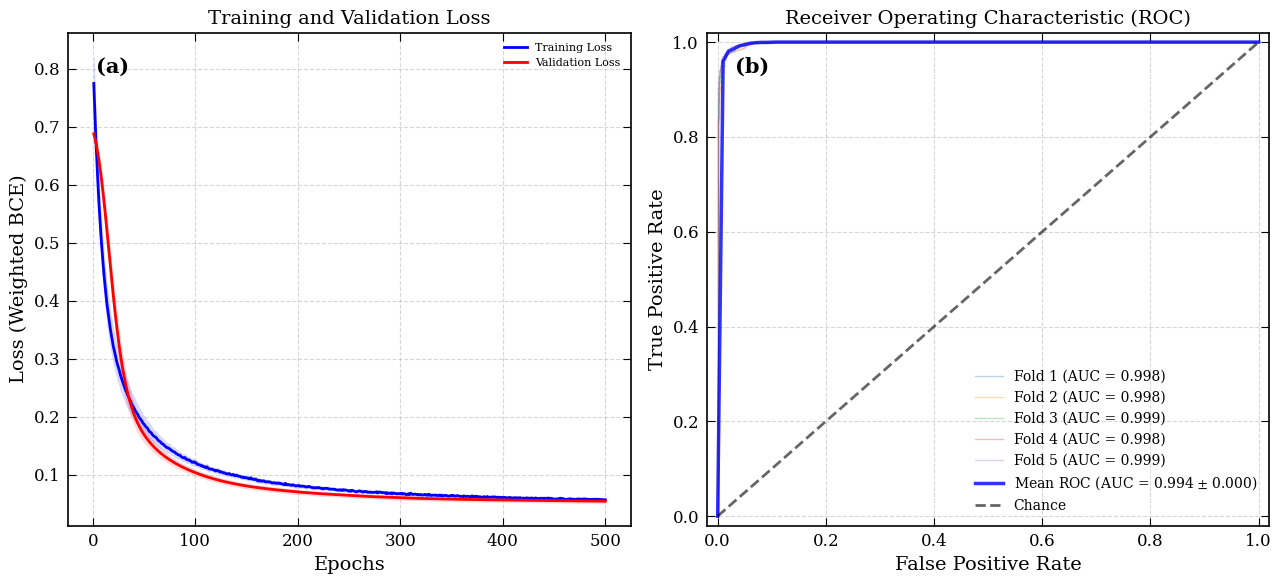

/tmp/ipykernel_3293909/4292040623.py:214: DeprecationWarning: Calling nonzero on 0d arrays is deprecated, as it behaves surprisingly. Use `atleast_1d(cond).nonzero()` if the old behavior was intended. If the context of this warning is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.
  rue_cuts = np.delete(rue_cuts, np.where(rue_cuts == reference_thresh)) # 删除 Nominal 的 cut


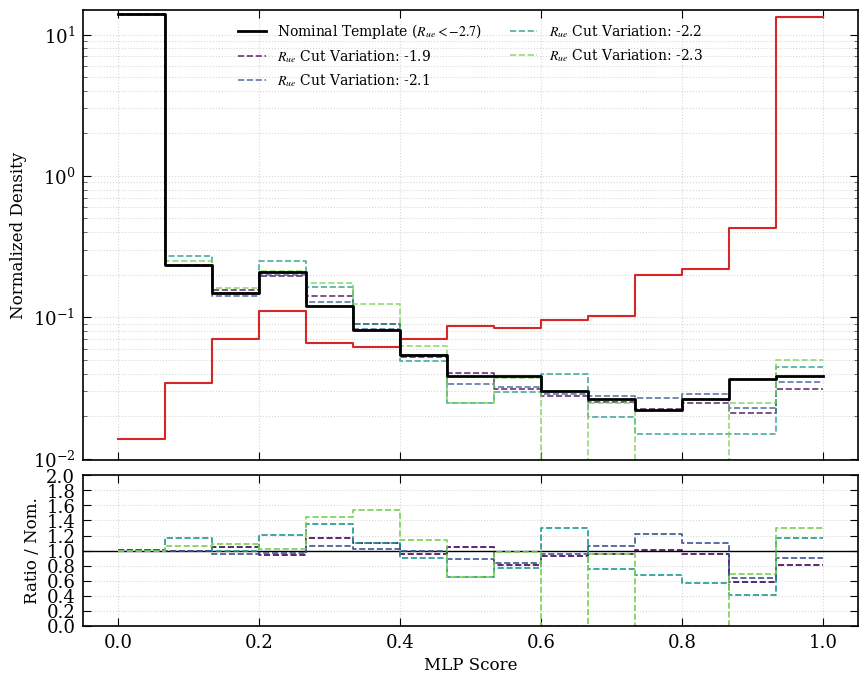

In [51]:


import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

# 设置全局绘图风格 (可选，如果没有安装 latex 可以注释掉 usetex=True)
def plot_training_evaluation(manager, output_dir="."):
    """
    绘制 Loss 曲线和 ROC 曲线
    """
    # 设置学术风格
    plt.style.use('seaborn-v0_8-paper')
    plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 14, 'xtick.labelsize': 12, 'ytick.labelsize': 12})
    
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    
    # ==========================================
    # 1. Loss Curve (Mean +/- Std)
    # ==========================================
    ax1 = axes[0]
    if manager.model_type == 'mlp' and manager.loss_histories:
        # 获取所有 fold 的 loss
        train_losses = np.array([h['train'] for h in manager.loss_histories])
        val_losses = np.array([h['val'] for h in manager.loss_histories])
        
        # 计算均值和标准差
        mean_train = np.mean(train_losses, axis=0)
        std_train = np.std(train_losses, axis=0)
        mean_val = np.mean(val_losses, axis=0)
        std_val = np.std(val_losses, axis=0)
        epochs = range(1, len(mean_train) + 1)
        
        # 绘图
        ax1.plot(epochs, mean_train, 'b-', label='Training Loss', lw=2)
        ax1.fill_between(epochs, mean_train - std_train, mean_train + std_train, color='b', alpha=0.15)
        
        ax1.plot(epochs, mean_val, 'r-', label='Validation Loss', lw=2)
        ax1.fill_between(epochs, mean_val - std_val, mean_val + std_val, color='r', alpha=0.15)
        
        ax1.set_xlabel('Epochs')
        ax1.set_ylabel('Loss (Weighted BCE)')
        ax1.text(0.05, 0.95, '(a)',  transform=ax1.transAxes, fontsize=15, fontweight='bold', va='top')
        ax1.set_title('Training and Validation Loss')
        ax1.legend(loc='upper right')
        ax1.grid(True, linestyle='--', alpha=0.5)
    else:
        ax1.text(0.5, 0.5, 'Loss history available only for MLP', ha='center', transform=ax1.transAxes)

    # ==========================================
    # 2. ROC Curve (K-Fold Mean)
    # ==========================================
    ax2 = axes[1]
    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)
    
    # 绘制每一折的 ROC
    for i, (y_true, y_score) in enumerate(manager.fold_roc_data):
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        # 插值以便计算平均
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        # 绘制浅色细线
        ax2.plot(fpr, tpr, lw=1, alpha=0.3, label=f'Fold {i+1} (AUC = {roc_auc:.3f})')
        
    # 绘制平均 ROC
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)
    
    ax2.plot(mean_fpr, mean_tpr, color='b', label=rf'Mean ROC (AUC = {mean_auc:.3f} $\pm$ {std_auc:.3f})', lw=2.5, alpha=0.8)
    
    # 绘制对角线
    ax2.plot([0, 1], [0, 1], linestyle='--', lw=2, color='k', label='Chance', alpha=0.6)
    
    ax2.set_xlim([-0.02, 1.02])
    ax2.set_ylim([-0.02, 1.02])
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title('Receiver Operating Characteristic (ROC)')
    ax2.text(0.05, 0.95, '(b)',  transform=ax2.transAxes, fontsize=15, fontweight='bold', va='top')
    ax2.legend(loc="lower right", fontsize=10)
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    fig.savefig(f"/data/home/zzh/Filt_Event/Note_Writing/figures/1e11_model_evaluation_metrics.pdf", dpi=300, bbox_inches='tight')
    plt.show()
    # 如果需要保存
   
plot_training_evaluation(manager)

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

# 设置全局绘图风格：Times New Roman 字体，向内的刻度
plt.rcParams.update({
    'font.family': 'serif',
    "font.serif": [ "DejaVu Serif", "serif"],
    'font.size': 12,
    'axes.labelsize': 15,
    'axes.titlesize': 16,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'legend.fontsize': 11,
    'legend.frameon': False,  # 去掉图例边框
    'figure.figsize': (10, 8),
    'axes.linewidth': 1.2     # 边框加粗
})

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

class Plotter:
    # 更加稳重、对比度高的学术配色
    COLORS = {
        'bkg_nom': 'black',      # 基准背景
        'signal':  '#d62728',    # 信号
        'data':    'black'       # 数据点
    }
    
    @staticmethod
    def plot_score(dfs, labels, weights, bins=50, title="MLP Score Distribution"):
        # 1. 设置画布与子图布局
        fig = plt.figure(figsize=(10, 8))
        gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
        ax1 = fig.add_subplot(gs[0])
        ax2 = fig.add_subplot(gs[1], sharex=ax1)

        hists = []
        raw_counts_list = []
        
        # 为变分背景生成渐变色，避免 "Sys. Var. 1" 这种模糊定义
        # 假设第 0 个是 Nominal，倒数第一个是 Signal
        n_sys = len(dfs) - 2 
        sys_colors = plt.cm.viridis(np.linspace(0, 0.8, n_sys)) if n_sys > 0 else []

        # =========================================================
        # 1. 主图绘制逻辑
        # =========================================================
        for i, (df, label, w) in enumerate(zip(dfs, labels, weights)):
            # 计算直方图 (Density=True 用于形态对比)
            h, edges = np.histogram(df['mlp_score'], bins=bins, range=(0, 1), weights=w, density=True)
            raw_n, _ = np.histogram(df['mlp_score'], bins=bins, range=(0, 1))
            
            centers = 0.5 * (edges[:-1] + edges[1:])
            hists.append(h)
            raw_counts_list.append(raw_n)
            
            # 绘图样式判定
            if i == 0: # Nominal Background
                ax1.step(edges, np.append(h, h[-1]), where='post', color=Plotter.COLORS['bkg_nom'], 
                        lw=2, zorder=10, label=label)
            elif i == len(dfs) - 1: # Signal
                # ax1.fill_between(centers, h, step="mid", color=Plotter.COLORS['signal'], 
                #                 alpha=0.2, label=label, zorder=1)
                ax1.step(edges, np.append(h, h[-1]), where='post', color=Plotter.COLORS['signal'], 
                        lw=1.5, zorder=2)
            else: # Variations
                ax1.step(edges, np.append(h, h[-1]), where='post', color=sys_colors[i-1], 
                        lw=1.2, alpha=0.8, ls='--', label=label)

        # 主图修饰
        ax1.set_yscale('log')
        ax1.set_ylabel('Normalized Density', fontsize=12)
        ax1.legend(loc='best', ncol=2, fontsize='small', frameon=False)
        ax1.grid(True, which='both', ls=':', alpha=0.5)
        # ax1.text(0.02, 0.95, title, transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top')
        ax1.set_ylim(None, 15) # 根据实际数据调整，确保高分段细节可见

        # =========================================================
        # 2. Ratio Plot 绘制逻辑
        # =========================================================
        ref_h = hists[0]
        
        ax2.axhline(1, color='black', lw=1, ls='-')
        # ax2.axhline(1.1, color='gray', lw=0.5, ls='--')
        # ax2.axhline(0.9, color='gray', lw=0.5, ls='--')

        for i in range(1, len(hists) - 1): # 只画背景的 Ratio
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio = hists[i] / ref_h
            
            ax2.step(edges, np.append(ratio, ratio[-1]), where='post', 
                     color=sys_colors[i-1], lw=1.2, ls='--')

        # Ratio 轴装饰
        ax2.set_ylabel('Ratio / Nom.', fontsize=12)
        ax2.set_xlabel('MLP Score', fontsize=12)
        ax2.set_ylim(0., 2) # 通常系统误差在这个范围内观察最清晰
        ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
        ax2.grid(True, ls=':', alpha=0.5)

        plt.setp(ax1.get_xticklabels(), visible=False)
        plt.savefig(f"/data/home/zzh/Filt_Event/Note_Writing/figures/1e11_score_distribution.pdf", dpi=300, bbox_inches='tight')
        plt.show()

# ==========================================
# 调用部分（优化标签显示）
# ==========================================
# 假设你的 bkg_var_final_list 是对应不同的 R_ue cut
rue_cuts =sideband_thresholds # 举例，请替换为你实际的 cut
rue_cuts = np.delete(rue_cuts, np.where(rue_cuts == reference_thresh)) # 删除 Nominal 的 cut

dfs_to_plot = [bkg_nominal_train, *bkg_var_final_list, sig_nominal_train]

# 这里的标签优化：直接显示物理参数的差异，不要用 Sys. Var. 1
labels = [
    r'Nominal Template ($R_{{ue}} < -2.7$)', 
    *[r'$R_{{ue}}$ Cut Variation: {}'.format(c) for c in rue_cuts[:len(bkg_var_final_list)]],
    r'Signal (IMM $10^{10}$ GeV)'
]

# 确保 TARGET_FLUX 变量已定义
# weights = [df[TARGET_FLUX] for df in dfs_to_plot[:-1]] + [sig_train_final['weight']]
# 这里简化一下你的权重逻辑：
weights_to_plot = []
for df in dfs_to_plot:
    if 'mlp_score' in df.columns:
        # 如果是信号，用 weight，如果是背景，用你算的 flux/norm weight
        w_col = 'weight' if 'trueE' in df.columns else TARGET_FLUX
        weights_to_plot.append(df[w_col])



Plotter.plot_score(dfs_to_plot, labels, weights_to_plot, bins=15, title="LHAASO-KM2A Monopole Search")


Bkg Var Max: [270.67445968   5.98662731   9.83191845   3.04982693   4.02380026
   1.57255194]
Bkg Var Min: [268.49194604   4.5730834    5.93000268   1.99709363   0.47960578
   0.83444094]
Bkg Nominal: [269.58320286   5.27985536   7.88096057   2.52346028   2.25170302
   1.20349644]
Bkg Max Diff: [1.09125682 0.70677195 1.95095789 0.52636665 1.77209724 0.3690555 ]
sig diff [ 2.37934485  2.61525643  2.88801611  6.28012915  4.82357969 49.39417921]


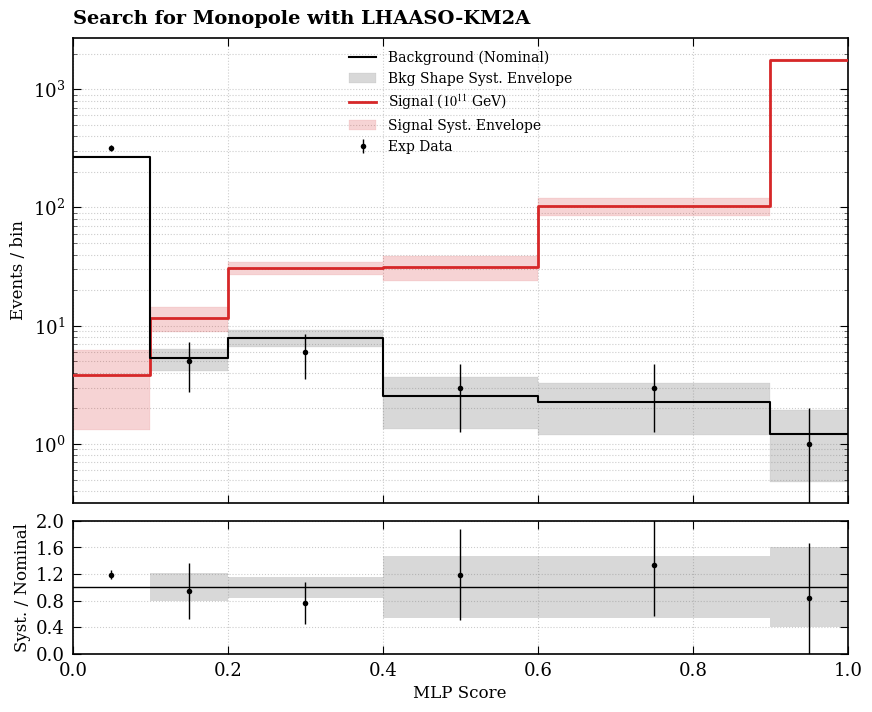

1952.9380410679307
288.72267852173036
338
Background scaling factor: 1.0000 (from 288.72 to 288.72)
>>> ROOT file for RooStats generated successfully.
>>> HistFactory XML configuration file generated successfully.


In [ ]:
def get_hist_counts(df, score_col='mlp_score', weight_col='weight', bins=25):
    
    counts, _ = np.histogram(df[score_col], bins=custom_bins, weights=df[weight_col])
    variances, _ = np.histogram(df[score_col], bins=custom_bins, weights=df[weight_col]**2)
    return counts, variances

from scipy.ndimage import gaussian_filter1d

def smooth_systematic_envelope(nominal, max_diff, sigma=1.0):
    """
    对系统误差的最大偏差进行平滑处理
    sigma: 平滑强度。通常设置在 1.0 - 1.5 之间。
           sigma 越大，曲线越平滑，但过大可能会抹去真实的物理趋势。
    """
    # 1. 对偏差进行平滑处理
    # 使用 mode='nearest' 处理边界，防止两端塌陷
    max_diff_smoothed = gaussian_filter1d(max_diff, sigma=sigma, mode='nearest')
    
    # 2. 重新生成对称包络线
    bkg_var_max_smoothed = nominal + max_diff_smoothed
    bkg_var_min_smoothed = nominal - max_diff_smoothed
    
    # 确保最小不会变成负数
    bkg_var_min_smoothed = np.maximum(bkg_var_min_smoothed, 0)
    
    return bkg_var_max_smoothed, bkg_var_min_smoothed


BINS_FIT = 10
BINS_PLOT = BINS_FIT
custom_bins = np.array([0.0, 0.1, 0.2, 0.4,  0.6,  0.9, 1.0])
exp_final_hist, exp_final_var = get_hist_counts(exp_data, bins=BINS_FIT)

bkg_nominal_final_hist, bkg_nominal_final_var = get_hist_counts(bkg_nominal_train, bins=BINS_FIT)
bkg_var_final_hists = [get_hist_counts(bkg_var, bins=BINS_FIT)[0] for bkg_var in bkg_var_final_list]
bkg_var_final_vars = [get_hist_counts(bkg_var, bins=BINS_FIT)[1] for bkg_var in bkg_var_final_list]

sig_final_hist, sig_final_var = get_hist_counts(sig_nominal_train, bins=BINS_FIT)
sig_var_final_hists = [get_hist_counts(sig_var, bins=BINS_FIT)[0] for sig_var in sig_var_final_list]
sig_var_final_vars = [get_hist_counts(sig_var, bins=BINS_FIT)[1] for sig_var in sig_var_final_list]


TIMESCALE_FACTOR = 1438.81 * 86400  # 将事件数转换为年事件数
sig_final_hist = sig_final_hist * TIMESCALE_FACTOR
sig_var_final_hists = [sig_var_hist * TIMESCALE_FACTOR for sig_var_hist in sig_var_final_hists]
bkg_nominal_fit = bkg_nominal_final_hist  # 使用原始的 nominal 作为拟合基础

# 找到每个 bin 在所有变分中的真实最大值和最小值
bkg_all_array = np.array([bkg_nominal_final_hist] + bkg_var_final_hists)
bkg_var_max_raw = np.max(bkg_all_array, axis=0)
bkg_var_min_raw = np.min(bkg_all_array, axis=0)
#==========================================================
# 然后分别对这两条线做平滑
# bkg_var_max = gaussian_filter1d(bkg_var_max_raw, sigma=1.2, mode='nearest')
# bkg_var_min = gaussian_filter1d(bkg_var_min_raw, sigma=1.2, mode='nearest')
#==========================================================
# 1. 计算相对偏差 (注意保留正负号)
# rel_diff_up = (bkg_var_max_raw - bkg_nominal_final_hist) / bkg_nominal_final_hist
# rel_diff_down = (bkg_var_min_raw - bkg_nominal_final_hist) / bkg_nominal_final_hist
# # 2. 对相对偏差做平滑 (Sigma 稍微小一点，防止把高分区的特征抹平)
# rel_diff_up_smooth = gaussian_filter1d(rel_diff_up, sigma=1.0)
# rel_diff_down_smooth = gaussian_filter1d(rel_diff_down, sigma=1.0)
# # 3. 得到最终包络线
# bkg_var_max = bkg_nominal_final_hist * (1 + rel_diff_up_smooth)
# bkg_var_min = bkg_nominal_final_hist * (1 + rel_diff_down_smooth)
#==========================================================
# 计算均值和标准差
# bkg_hist_variations = np.array([bkg_var for bkg_var in bkg_var_final_hists])
# bkg_hist_variations_std = np.std(bkg_hist_variations, axis=0)
# bkg_hist_variations_mean = np.mean(bkg_hist_variations, axis=0)
# print("Bkg Variations Mean:", bkg_hist_variations_mean)
# print("Bkg Variations Std Dev:", bkg_hist_variations_std)
# bkg_var_max = bkg_hist_variations_mean + bkg_hist_variations_std
# bkg_var_min = bkg_hist_variations_mean - bkg_hist_variations_std
#==========================================================
#==========================================================
# 找到偏离最大,然后做对称镜像
bkg_hist_variations_diff = np.array([bkg_var - bkg_nominal_final_hist for bkg_var in bkg_var_final_hists])
bkg_hist_variations_diff = np.abs(bkg_hist_variations_diff)
bkg_hist_max_diff = np.max(bkg_hist_variations_diff, axis=0)
bkg_var_max = bkg_nominal_final_hist + bkg_hist_max_diff
bkg_var_min = bkg_nominal_final_hist - bkg_hist_max_diff
bkg_var_min = np.maximum(bkg_var_min, 1e-5) # 确保最小值不为负数
print("Bkg Var Max:", bkg_var_max)
print("Bkg Var Min:", bkg_var_min)
print("Bkg Nominal:", bkg_nominal_final_hist)
print("Bkg Max Diff:", bkg_hist_max_diff)
#==========================================================
# # 计算相对偏差
# rel_diff = bkg_hist_max_diff / bkg_nominal_final_hist
# x = np.linspace(0, 1, len(rel_diff))
# # 使用 2 阶多项式拟合趋势
# poly_coeffs = np.polyfit(x, rel_diff, 2)
# rel_diff_smoothed = np.polyval(poly_coeffs, x)
# # 重新应用
# bkg_var_max = bkg_nominal_final_hist * (1 + rel_diff_smoothed)
# bkg_var_min = bkg_nominal_final_hist * (1 - rel_diff_smoothed)
#==========================================================
# 调用平滑函数
# 建议先从 sigma=1.0 开始尝试
# 强制将 bkg_hist_max_diff 转换为 float 数组
bkg_var_max, bkg_var_min = smooth_systematic_envelope(bkg_nominal_final_hist.astype(float), bkg_hist_max_diff.astype(float), sigma=1)
#==========================================================
#sig var
sig_hist_variations = np.array([sig_var - sig_final_hist for sig_var in sig_var_final_hists])
sig_hist_variations_diff = np.abs(sig_hist_variations)
sig_hist_max_diff = np.max(sig_hist_variations_diff, axis=0)
sig_var_max, sig_var_min = smooth_systematic_envelope(sig_final_hist.astype(float), sig_hist_max_diff.astype(float), sigma=1)
print("sig diff", sig_hist_max_diff)
#==========================================================




import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# 设置学术图表的默认样式
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.usetex'] = False # 如果你有 LaTeX 环境，设为 True 会更美观
def plot_final_with_full_envelope(nominal_bkg, bkg_max, bkg_min, signal, exp_data_hist, edges,
                                  sig_max, sig_min):
    """
    绘制带有不等宽分箱系统误差阴影带的图表
    edges: bin_edges, 长度为 n_bins + 1
    """
    # 转换为 float 保证计算安全
    bkg_max = np.asarray(bkg_max, dtype=float)
    bkg_min = np.asarray(bkg_min, dtype=float)
    nominal_bkg = np.asarray(nominal_bkg, dtype=float)
    signal = np.asarray(signal, dtype=float)
    sig_max = np.asarray(sig_max, dtype=float)
    sig_min = np.asarray(sig_min, dtype=float)
    exp_data_hist = np.asarray(exp_data_hist, dtype=float)
    edges = np.asarray(edges, dtype=float)

    # 计算 bin centers 和 widths (用于不等宽处理)
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)

    # 创建画布
    fig = plt.figure(figsize=(10, 8))
    gs = fig.add_gridspec(2, 1, height_ratios=[3.5, 1], hspace=0.06)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)

    # =========================================================
    # 主图 (ax1): 不等宽阶梯填充
    # =========================================================
    
    # A. 绘制背景系统误差阴影带 (使用 step='post')
    # 为了让 step='post' 覆盖到最后一个 edge，需要在数组末尾补一个值
    # B. 绘制背景 Nominal 阶梯线
    ax1.step(edges, np.append(nominal_bkg, nominal_bkg[-1]), where='post', 
             color='black', lw=1.5, label='Background (Nominal)', zorder=10)
    ax1.fill_between(edges, 
                     np.append(bkg_min, bkg_min[-1]), 
                     np.append(bkg_max, bkg_max[-1]), 
                     step='post', color='gray', alpha=0.3, 
                     label='Bkg Shape Syst. Envelope', zorder=1)

    
    
    # C. 绘制信号阶梯线
    ax1.step(edges, np.append(signal, signal[-1]), where='post', 
             color='#d62728', lw=2, label='Signal ($10^{11}$ GeV)', zorder=5)
    ax1.fill_between(edges,
                     np.append(sig_min, sig_min[-1]),
                     np.append(sig_max, sig_max[-1]),
                     step='post', color='#d62728', alpha=0.2, label='Signal Syst. Envelope', zorder=2)
                    
    # D. 绘制实验数据 (点状带误差棒)
    # 统计误差使用 sqrt(N)，注意：数据点的 X 坐标必须在 centers
    ax1.errorbar(centers, exp_data_hist, yerr=np.sqrt(exp_data_hist), 
                 fmt='ko', markersize=4, capsize=0, elinewidth=1, label='Exp Data', zorder=15)
    
    # 主图修饰
    ax1.set_yscale('log')
    ax1.set_ylabel('Events / bin', fontsize=12)
    ax1.set_xlim(edges[0], edges[-1])
    ax1.legend(loc='best', frameon=False, fontsize=10)
    ax1.grid(True, which='both', ls=':', alpha=0.4, color='gray')
    ax1.set_title("Search for Monopole with LHAASO-KM2A", loc='left', fontsize=14, fontweight='bold', pad=10)
    plt.setp(ax1.get_xticklabels(), visible=False)

    # =========================================================
    # 子图 (ax2): 不等宽 Ratio Plot
    # =========================================================
    
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_data = exp_data_hist / nominal_bkg
        ratio_max = bkg_max / nominal_bkg
        ratio_min = bkg_min / nominal_bkg
        # 处理可能出现的除以0的情况
        ratio_data = np.nan_to_num(ratio_data)
    
    # A. 绘制系统误差带 (Bar 方式完美适配不等宽)
    # 给 bar 传入 widths 数组，使得每个柱子宽度与 bin 宽度一致
    ax2.bar(centers, ratio_max - ratio_min, bottom=ratio_min, width=widths,
            color='gray', alpha=0.3, align='center', zorder=1)
    
    # B. 绘制 Data/Nominal 点
    ax2.errorbar(centers, ratio_data, yerr=np.sqrt(exp_data_hist)/nominal_bkg, 
                 fmt='ko', markersize=4, capsize=0, elinewidth=1, zorder=10)
    
    # 1.0 参考线
    ax2.axhline(1.0, color='black', lw=1, ls='-')
    
    # 子图修饰
    ax2.set_ylabel('Syst. / Nominal', fontsize=12)
    ax2.set_xlabel('MLP Score', fontsize=12)
    ax2.set_ylim(0.0, 2.0) # 根据实际偏移调整范围
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.4)) 
    ax2.grid(True, which='both', ls=':', alpha=0.4, color='gray')
    plt.savefig(f"/data/home/zzh/Filt_Event/Note_Writing/figures/1e11_pre-fit_with_envelope.pdf", dpi=300, bbox_inches='tight')
    plt.show()

plot_final_with_full_envelope(bkg_nominal_fit, bkg_var_max, bkg_var_min, sig_final_hist, exp_final_hist, custom_bins, sig_var_max, sig_var_min)
print(sig_final_hist.sum())
print(bkg_nominal_final_hist.sum())
print(exp_final_hist.sum())


import array
import ROOT
import numpy as np

# --- 0. 准备工作 ---
# 假设你的 MLP Score 范围是 [0, 1]，40 个 bin
BINS_EDGES = np.linspace(0, 1, len(exp_final_hist)+1) # 这里的 bin 数量要和 hist 的长度匹配
BINS_ARRAY = array.array('d', BINS_EDGES)

# 核心：计算背景缩放系数
# 将模板直方图的总面积缩放到 Sideband Fit 预测的 Total_Yield
current_bkg_integral = np.sum(bkg_nominal_final_hist)
bkg_scale = bkg_yields / current_bkg_integral
print(f"Background scaling factor: {bkg_scale:.4f} (from {current_bkg_integral:.2f} to {bkg_yields:.2f})")
def write_hist_pyroot(file_obj, name, counts, variances, bin_edges_array):
    """使用 PyROOT 写入直方图"""
    h = ROOT.TH1D(name, name, len(bin_edges_array)-1, bin_edges_array)
    h.Sumw2()
    for i in range(len(counts)):
        h.SetBinContent(i+1, counts[i])
        if variances is not None:
            h.SetBinError(i+1, np.sqrt(variances[i]))
        else:
            # 对于数据，默认使用泊松误差
            h.SetBinError(i+1, np.sqrt(counts[i]))
    h.SetDirectory(file_obj)
    h.Write()

# --- 1. 执行写入 ---
import os
os.makedirs("./upperlimit_DataDriven", exist_ok=True)
os.makedirs("./upperlimit_DataDriven/figures", exist_ok=True)
os.makedirs("./upperlimit_DataDriven/results", exist_ok=True)
f_out = ROOT.TFile("./upperlimit_DataDriven/inputs_for_roostats.root", "RECREATE")

# A. 写入 Data
write_hist_pyroot(f_out, "h_data", exp_final_hist, exp_final_var, BINS_ARRAY)

# B. 写入 Signal (已经乘以 TIMESCALE_FACTOR)
write_hist_pyroot(f_out, "h_sig_nom", sig_final_hist, sig_final_var, BINS_ARRAY)

# C. 写入 Background Nominal (缩放到预测产额)
# 注意：方差也要按比例平方缩放
write_hist_pyroot(f_out, "h_bkg_nom", 
                  bkg_nominal_final_hist * bkg_scale, 
                  bkg_nominal_final_var * (bkg_scale**2), 
                  BINS_ARRAY)

# D. 写入 Background Shape Systematics (Up/Down)
# HistFactory 的 HistoSys 需要 Up 和 Down 两个模板
write_hist_pyroot(f_out, "h_bkg_ShapeUp", 
                  bkg_var_max * bkg_scale, 
                  None, BINS_ARRAY) # 变分模板通常不单独计算 MC 统计误差
write_hist_pyroot(f_out, "h_bkg_ShapeDown", 
                  bkg_var_min * bkg_scale, 
                  None, BINS_ARRAY)
write_hist_pyroot(f_out, "h_sig_ShapeUp",
                  sig_var_max,
                  None, BINS_ARRAY)
write_hist_pyroot(f_out, "h_sig_ShapeDown",
                  sig_var_min,
                  None, BINS_ARRAY)
f_out.Close()
print(">>> ROOT file for RooStats generated successfully.")

XMLcontent=r"""
<!DOCTYPE Channel  SYSTEM 'HistFactorySchema.dtd'>

<Channel Name="LHAASO_Monopole_Channel" InputFile="./inputs_for_roostats.root">

  <Data HistoName="h_data" />
  <StatErrorConfig RelErrorThreshold="0.001" ConstraintType="Poisson" />

  <Sample Name="Background" HistoName="h_bkg_nom" NormalizeByTheory="True">
    <StatError Activate="True" />
    <NormFactor Name="mu_bkg" Val="1.0" Low="0.0" High="5.0" />
    <HistoSys Name="BkgShapeSyst" HistoNameLow="h_bkg_ShapeDown" HistoNameHigh="h_bkg_ShapeUp" />
  </Sample>

  <Sample Name="Signal" HistoName="h_sig_nom" NormalizeByTheory="True">
    <StatError Activate="True" />
    <NormFactor Name="mu" Val="1.0" Low="0.0" High="10.0" />
    <OverallSys Name="recE_shift" Low="0.80" High="1.20" />
    <OverallSys Name="R_ue_shift" Low="0.80" High="1.20" />
    <OverallSys Name="thetaRec_resolution" Low="0.80" High="1.20" />
    <HistoSys Name="SigShapeSyst" HistoNameLow="h_sig_ShapeDown" HistoNameHigh="h_sig_ShapeUp" />
  </Sample>

</Channel>


"""

XMLcontent = XMLcontent.replace('Name="recE_shift" Low="0.80" High="1.20"', f'Name="recE_shift" Low="{1-sig_recE_sys_percent:.4f}" High="{1+sig_recE_sys_percent:.4f}"')
XMLcontent = XMLcontent.replace('Name="R_ue_shift" Low="0.80" High="1.20"', f'Name="R_ue_shift" Low="{1-sig_Rue_sys_percent:.4f}" High="{1+sig_Rue_sys_percent:.4f}"')
XMLcontent = XMLcontent.replace('Name="thetaRec_resolution" Low="0.80" High="1.20"', f'Name="thetaRec_resolution" Low="{1-rec_theta_uncertainty_most:.4f}" High="{1+rec_theta_uncertainty_most:.4f}"')
with open("./upperlimit_DataDriven/LHAASO_Channel.xml", "w") as f:
    f.write(XMLcontent)
print(">>> HistFactory XML configuration file generated successfully.")

# cd ~/Filt_Event/UpperLimit/1e11/upperlimit_DataDriven
# hist2workspace driver.xml && root -l -b -q RunLimit_Plot.C

In [154]:

import array
import ROOT
import numpy as np

# --- 0. 准备工作 ---
# 假设你的 MLP Score 范围是 [0, 1]，40 个 bin
BINS_EDGES = custom_bins # 这里的 bin 数量要和 hist 的长度匹配
BINS_ARRAY = array.array('d', BINS_EDGES)

# 核心：计算背景缩放系数
# 将模板直方图的总面积缩放到 Sideband Fit 预测的 Total_Yield
current_bkg_integral = np.sum(bkg_nominal_final_hist)
bkg_scale = Total_Yield / current_bkg_integral

def write_hist_pyroot(file_obj, name, counts, variances, bin_edges_array):
    """使用 PyROOT 写入直方图"""
    h = ROOT.TH1D(name, name, len(bin_edges_array)-1, bin_edges_array)
    h.Sumw2()
    for i in range(len(counts)):
        h.SetBinContent(i+1, counts[i])
        if variances is not None:
            h.SetBinError(i+1, np.sqrt(variances[i]))
        else:
            # 对于数据，默认使用泊松误差
            h.SetBinError(i+1, np.sqrt(counts[i]))
    h.SetDirectory(file_obj)
    h.Write()

# --- 1. 执行写入 ---
import os
os.makedirs("./upperlimit_DataDriven", exist_ok=True)
os.makedirs("./upperlimit_DataDriven/figures", exist_ok=True)
os.makedirs("./upperlimit_DataDriven/results", exist_ok=True)
f_out = ROOT.TFile("./upperlimit_DataDriven/inputs_for_roostats.root", "RECREATE")

# A. 写入 Data
write_hist_pyroot(f_out, "h_data", exp_final_hist, exp_final_var, BINS_ARRAY)

# B. 写入 Signal (已经乘以 TIMESCALE_FACTOR)
write_hist_pyroot(f_out, "h_sig_nom", sig_final_hist, sig_final_var, BINS_ARRAY)

# C. 写入 Background Nominal (缩放到预测产额)
# 注意：方差也要按比例平方缩放
write_hist_pyroot(f_out, "h_bkg_nom", 
                  bkg_nominal_final_hist * bkg_scale, 
                  bkg_nominal_final_var * (bkg_scale**2), 
                  BINS_ARRAY)

# D. 写入 Background Shape Systematics (Up/Down)
# HistFactory 的 HistoSys 需要 Up 和 Down 两个模板
write_hist_pyroot(f_out, "h_bkg_ShapeUp", 
                  bkg_var_max * bkg_scale, 
                  None, BINS_ARRAY) # 变分模板通常不单独计算 MC 统计误差
write_hist_pyroot(f_out, "h_bkg_ShapeDown", 
                  bkg_var_min * bkg_scale, 
                  None, BINS_ARRAY)

f_out.Close()
print(">>> ROOT file for RooStats generated successfully.")

XMLcontent=r"""
<!DOCTYPE Channel  SYSTEM 'HistFactorySchema.dtd'>

<Channel Name="LHAASO_Monopole_Channel" InputFile="./inputs_for_roostats.root">

  <Data HistoName="h_data" />
  <StatErrorConfig RelErrorThreshold="0.001" ConstraintType="Poisson" />

  <Sample Name="Background" HistoName="h_bkg_nom" NormalizeByTheory="True">
    <StatError Activate="True" />
    <NormFactor Name="mu_bkg" Val="1.0" Low="0.0" High="5.0" />
    <OverallSys Name="BkgNormUnc" Low="0.88" High="1.12" /> 
    <HistoSys Name="BkgShapeSyst" HistoNameLow="h_bkg_ShapeDown" HistoNameHigh="h_bkg_ShapeUp" />
  </Sample>

  <Sample Name="Signal" HistoName="h_sig_nom" NormalizeByTheory="True">
    <StatError Activate="True" />
    <NormFactor Name="mu" Val="1.0" Low="0.0" High="10.0" />
  </Sample>

</Channel>


"""

xml_content_final = XMLcontent.replace('Low="0.80" High="1.20"', f'Low="{1-uncertainty_ratio:.2f}" High="{1+uncertainty_ratio:.2f}"')
with open("./upperlimit_DataDriven/LHAASO_Channel.xml", "w") as f:
    f.write(xml_content_final)
print(">>> HistFactory XML configuration file generated successfully.")

# cd ~/Filt_Event/UpperLimit/1e11/upperlimit_DataDriven
# hist2workspace driver.xml && root -l -b -q RunLimit_Plot.C
# hist2workspace driver.xml && root -l -b -q RunLimit_Frequentist.C
# hist2workspace driver.xml && time root -l -b -q Stable_CLs.C

>>> ROOT file for RooStats generated successfully.
>>> HistFactory XML configuration file generated successfully.
